In [ ]:
import sys
import subprocess
import pandas as pd
import numpy as np
import gc
import transformers
import requests
import evaluate
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
import tweepy
import openai
from openai import OpenAI
import json
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import streamlit as st
import nltk
from scipy.sparse import hstack
from nltk.corpus import stopwords
from collections import Counter
from xgboost import XGBClassifier
import torch
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments
)

import torch
import torch.nn as nn

from transformers import RobertaModel
from transformers.modeling_outputs import SequenceClassifierOutput

from datasets import Dataset

# Step 0: Connecting to SQL Database

In [2]:
# Verify Database and proper tokens exist in .env file
from dotenv import load_dotenv

load_dotenv()

print("Database URL found:", os.getenv("DATABASE_URL") is not None)
print("Twitter token found:", os.getenv("X_BEARER_TOKEN") is not None)

Database URL found: True
Twitter token found: True


In [3]:
# Connect to the database and run a simple query to verify connection
from sqlalchemy import create_engine, text

engine = create_engine(os.getenv("DATABASE_URL"))

with engine.connect() as conn:
    result = conn.execute(
        text("SELECT current_database(), current_user")
    )
    
    print(result.fetchone())

('twitter_engagement', 'postgres')


In [4]:
# Verify tables exist in the database
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name
"""

with engine.connect() as conn:
    result = conn.execute(text(query))

    for row in result:
        print(row[0])

tweet_labels
tweet_media
tweet_modeling_dataset
tweets
users


# Step 1: Getting Twitter Data

In [5]:
import os
import re
import json
import pandas as pd
import tweepy

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()

engine = create_engine(os.getenv("DATABASE_URL"))

client = tweepy.Client(
    bearer_token=os.getenv("X_BEARER_TOKEN"),
    wait_on_rate_limit=True
)

print("Setup complete")

Setup complete


In [6]:
# Text cleaning function
def clean_tweet_text(text):
    if text is None:
        return None
    
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "@USER", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

In [10]:
# Defining time windows and test queries for data collection
from datetime import datetime, timedelta, timezone
import pandas as pd

now = datetime.now(timezone.utc)

# Each tuple is: (start_days_ago, end_days_ago)
# Example: 7.0 to 6.8 days ago means older tweets with time to gain engagement.
time_windows = [
    (7.0, 6.8),
    (6.8, 6.6),
    (6.6, 6.4),
    (6.4, 6.2),
    (6.2, 6.0)
]

test_queries = {
    "broad_general": '("the" OR "this" OR "you" OR "that" OR "with") lang:en -is:retweet',
    "questions": '("why" OR "how" OR "what" OR "when" OR "where") lang:en -is:retweet',
    "opinions": '("best" OR "worst" OR "favorite" OR "overrated" OR "underrated") lang:en -is:retweet',
    "entertainment": '("movie" OR "music" OR "game" OR "show" OR "book") lang:en -is:retweet',
    "life_topics": '("food" OR "travel" OR "work" OR "school" OR "fitness") lang:en -is:retweet'
}


In [11]:
# Test collection
all_responses = []

for query_name, query_text in test_queries.items():
    for start_days, end_days in time_windows:
        start_time = now - timedelta(days=start_days)
        end_time = now - timedelta(days=end_days)

        start_time_str = start_time.isoformat(timespec="seconds").replace("+00:00", "Z")
        end_time_str = end_time.isoformat(timespec="seconds").replace("+00:00", "Z")

        response = client.search_recent_tweets(
            query=query_text,
            max_results=10,
            start_time=start_time_str,
            end_time=end_time_str,
            sort_order="relevancy",
            tweet_fields=[
                "created_at",
                "author_id",
                "lang",
                "public_metrics",
                "entities",
                "attachments",
                "referenced_tweets"
            ],
            expansions=[
                "attachments.media_keys",
                "author_id",
                "referenced_tweets.id"
            ],
            media_fields=[
                "media_key",
                "type",
                "url",
                "preview_image_url",
                "alt_text",
                "width",
                "height",
                "duration_ms",
                "public_metrics"
            ],
            user_fields=[
                "username",
                "name",
                "verified",
                "public_metrics"
            ]
        )

        tweet_count = 0 if response.data is None else len(response.data)

        print(
            f"{query_name} | {start_time_str} to {end_time_str} | tweets returned: {tweet_count}"
        )

        all_responses.append({
            "query_name": query_name,
            "query_text": query_text,
            "start_time": start_time_str,
            "end_time": end_time_str,
            "response": response,
            "tweet_count": tweet_count
        })

print("Total API calls made:", len(all_responses))
print("Total tweets returned before deduping:", sum(r["tweet_count"] for r in all_responses))

broad_general | 2026-06-04T18:59:35Z to 2026-06-04T23:47:35Z | tweets returned: 10
broad_general | 2026-06-04T23:47:35Z to 2026-06-05T04:35:35Z | tweets returned: 10
broad_general | 2026-06-05T04:35:35Z to 2026-06-05T09:23:35Z | tweets returned: 10
broad_general | 2026-06-05T09:23:35Z to 2026-06-05T14:11:35Z | tweets returned: 10
broad_general | 2026-06-05T14:11:35Z to 2026-06-05T18:59:35Z | tweets returned: 10
questions | 2026-06-04T18:59:35Z to 2026-06-04T23:47:35Z | tweets returned: 10
questions | 2026-06-04T23:47:35Z to 2026-06-05T04:35:35Z | tweets returned: 9
questions | 2026-06-05T04:35:35Z to 2026-06-05T09:23:35Z | tweets returned: 10
questions | 2026-06-05T09:23:35Z to 2026-06-05T14:11:35Z | tweets returned: 10
questions | 2026-06-05T14:11:35Z to 2026-06-05T18:59:35Z | tweets returned: 10
opinions | 2026-06-04T18:59:35Z to 2026-06-04T23:47:35Z | tweets returned: 10
opinions | 2026-06-04T23:47:35Z to 2026-06-05T04:35:35Z | tweets returned: 9
opinions | 2026-06-05T04:35:35Z to 2

In [12]:
# Vareity check

test_rows = []

for item in all_responses:
    response = item["response"]

    for tweet in response.data or []:
        metrics = tweet.public_metrics or {}

        test_rows.append({
            "tweet_id": str(tweet.id),
            "query_name": item["query_name"],
            "start_time_window": item["start_time"],
            "end_time_window": item["end_time"],
            "created_at": tweet.created_at,
            "text": tweet.text,
            "like_count": metrics.get("like_count", 0),
            "reply_count": metrics.get("reply_count", 0),
            "retweet_count": metrics.get("retweet_count", 0),
            "quote_count": metrics.get("quote_count", 0),
        })

test_df = pd.DataFrame(test_rows)

test_df["engagement_total"] = (
    test_df["like_count"] +
    test_df["reply_count"] +
    test_df["retweet_count"] +
    test_df["quote_count"]
)

test_df = test_df.drop_duplicates(subset="tweet_id")

print("Unique tweets:", len(test_df))
print("Unique queries represented:", test_df["query_name"].nunique())
print("Created_at range:", test_df["created_at"].min(), "to", test_df["created_at"].max())

display(
    test_df[[
        "query_name",
        "created_at",
        "like_count",
        "reply_count",
        "retweet_count",
        "quote_count",
        "engagement_total",
        "text"
    ]]
    .sort_values("engagement_total", ascending=False)
    .head(25)
)

Unique tweets: 243
Unique queries represented: 5
Created_at range: 2026-06-04 19:00:30+00:00 to 2026-06-05 18:44:39+00:00


,query_name,created_at,like_count,reply_count,retweet_count,quote_count,engagement_total,text
169,entertainment,2026-06-05 08:18:54+00:00,2798,40,367,16,3221,In the Game Boy Color educational game Blue's ...
198,life_topics,2026-06-04 19:17:15+00:00,599,221,47,249,1116,What fast food spot did you work at? I worked ...
192,entertainment,2026-06-05 18:32:07+00:00,647,7,10,0,664,My favorite Bond book is Moonraker for this ve...
203,life_topics,2026-06-04 21:25:26+00:00,326,37,99,6,468,Connecticut is spending millions of your tax m...
34,broad_general,2026-06-05 12:55:49+00:00,308,4,129,12,453,𝙐𝙉𝘿𝙀𝙍 𝙏𝙃𝙀 𝙈𝙊𝙊𝙉 𝘼𝙉𝘿 𝙎𝙏𝘼𝙍𝙎 🌙✨\n\n𝙎𝙤𝙢𝙚 𝙣𝙞𝙜𝙝𝙩𝙨 𝙚𝙣𝙙...
28,broad_general,2026-06-05 04:35:36+00:00,343,39,19,1,402,In bear markets you absolutely just do not buy...
208,life_topics,2026-06-05 03:32:16+00:00,297,25,10,0,332,The worst form of fitness is when you start th...
145,opinions,2026-06-05 14:14:32+00:00,222,28,13,20,283,Who’s the most overrated / underrated Monarch ...
48,broad_general,2026-06-05 14:44:05+00:00,235,30,5,1,271,@PhiloGroves Let me explain why this happens. ...
78,questions,2026-06-05 08:00:01+00:00,126,139,2,1,268,i think people often confuse performance with ...


In [13]:
# DataFrame creation from multiple query/time-window responses

tweet_rows = []
media_rows = []
user_rows = []

for item in all_responses:
    response = item["response"]
    query_name = item["query_name"]
    query_text = item["query_text"]
    start_time_window = item["start_time"]
    end_time_window = item["end_time"]

    tweets = response.data or []
    includes = response.includes or {}

    media_lookup = {
        media.data["media_key"]: media
        for media in includes.get("media", [])
    }

    # users
    for user in includes.get("users", []):
        metrics = user.data.get("public_metrics", {})

        user_rows.append({
            "author_id": str(user.id),
            "username": user.data.get("username"),
            "name": user.data.get("name"),
            "verified": user.data.get("verified"),
            "followers_count": metrics.get("followers_count", 0),
            "following_count": metrics.get("following_count", 0),
            "tweet_count": metrics.get("tweet_count", 0),
            "listed_count": metrics.get("listed_count", 0),
            "raw_json": json.dumps(user.data)
        })

    # tweets and media
    for tweet in tweets:
        metrics = tweet.public_metrics or {}
        attachments = tweet.data.get("attachments", {})
        media_keys = attachments.get("media_keys", [])

        tweet_rows.append({
            "tweet_id": str(tweet.id),
            "author_id": str(tweet.author_id),
            "created_at": tweet.created_at,
            "text": tweet.text,
            "clean_text": clean_tweet_text(tweet.text),
            "lang": tweet.lang,

            "retweet_count": metrics.get("retweet_count", 0),
            "reply_count": metrics.get("reply_count", 0),
            "like_count": metrics.get("like_count", 0),
            "quote_count": metrics.get("quote_count", 0),

            "has_media": len(media_keys) > 0,
            "media_count": len(media_keys),

            "collection_source": query_name,
            "search_query": query_text,

            # useful for testing; not currently in your database unless you add columns
            "start_time_window": start_time_window,
            "end_time_window": end_time_window,

            "raw_json": json.dumps(tweet.data)
        })

        for media_key in media_keys:
            media = media_lookup.get(media_key)

            if media is None:
                continue

            media_rows.append({
                "media_key": media_key,
                "tweet_id": str(tweet.id),
                "media_type": media.data.get("type"),
                "url": media.data.get("url"),
                "preview_image_url": media.data.get("preview_image_url"),
                "alt_text": media.data.get("alt_text"),
                "width": media.data.get("width"),
                "height": media.data.get("height"),
                "duration_ms": media.data.get("duration_ms"),
                "public_metrics": json.dumps(media.data.get("public_metrics", {})),
                "raw_json": json.dumps(media.data)
            })

tweets_df = pd.DataFrame(tweet_rows)
media_df = pd.DataFrame(media_rows)
users_df = pd.DataFrame(user_rows)

# Deduplicate
if len(tweets_df) > 0:
    tweets_df = tweets_df.drop_duplicates(subset="tweet_id").copy()

if len(media_df) > 0:
    media_df = media_df.drop_duplicates(subset="media_key").copy()

if len(users_df) > 0:
    users_df = users_df.drop_duplicates(subset="author_id").copy()

# Engagement features
if len(tweets_df) > 0:
    tweets_df["engagement_total"] = (
        tweets_df["like_count"] +
        tweets_df["reply_count"] +
        tweets_df["retweet_count"] +
        tweets_df["quote_count"]
    )

    tweets_df = tweets_df.sort_values(by="engagement_total", ascending=False)



tweets_df["eligible_for_labeling"] = (
    tweets_df["engagement_total"] >= 2
)

# Propagate eligible_for_labeling to media_df and users_df
tweet_eligibility_lookup = (
    tweets_df
    .set_index("tweet_id")["eligible_for_labeling"]
    .to_dict()
)

user_eligibility_lookup = (
    tweets_df
    .groupby("author_id")["eligible_for_labeling"]
    .any()
    .to_dict()
)

if len(media_df) > 0:
    media_df["eligible_for_labeling"] = (
        media_df["tweet_id"]
        .map(tweet_eligibility_lookup)
        .fillna(False)
    )
else:
    media_df["eligible_for_labeling"] = pd.Series(dtype=bool)

if len(users_df) > 0:
    users_df["eligible_for_labeling"] = (
        users_df["author_id"]
        .map(user_eligibility_lookup)
        .fillna(False)
    )
else:
    users_df["eligible_for_labeling"] = pd.Series(dtype=bool)

display(tweets_df.head())
display(media_df.head())
display(users_df.head())

,tweet_id,author_id,created_at,text,clean_text,lang,retweet_count,reply_count,like_count,quote_count,has_media,media_count,collection_source,search_query,start_time_window,end_time_window,raw_json,engagement_total,eligible_for_labeling
169,2062811385613156799,1805986061467951104,2026-06-05 08:18:54+00:00,In the Game Boy Color educational game Blue's ...,In the Game Boy Color educational game Blue's ...,en,367,40,2798,16,True,1,entertainment,"(""movie"" OR ""music"" OR ""game"" OR ""show"" OR ""bo...",2026-06-05T04:35:35Z,2026-06-05T09:23:35Z,"{""entities"": {""urls"": [{""start"": 222, ""end"": 2...",3221,True
198,2062614676660187382,94844786,2026-06-04 19:17:15+00:00,What fast food spot did you work at? I worked ...,What fast food spot did you work at? I worked ...,en,47,221,599,249,False,0,life_topics,"(""food"" OR ""travel"" OR ""work"" OR ""school"" OR ""...",2026-06-04T18:59:35Z,2026-06-04T23:47:35Z,"{""author_id"": ""94844786"", ""edit_history_tweet_...",1116,True
192,2062965706996723879,1668704081102389249,2026-06-05 18:32:07+00:00,My favorite Bond book is Moonraker for this ve...,My favorite Bond book is Moonraker for this ve...,en,10,7,647,0,False,0,entertainment,"(""movie"" OR ""music"" OR ""game"" OR ""show"" OR ""bo...",2026-06-05T14:11:35Z,2026-06-05T18:59:35Z,"{""author_id"": ""1668704081102389249"", ""edit_his...",664,True
203,2062646937158140250,62812958,2026-06-04 21:25:26+00:00,Connecticut is spending millions of your tax m...,Connecticut is spending millions of your tax m...,en,99,37,326,6,False,0,life_topics,"(""food"" OR ""travel"" OR ""work"" OR ""school"" OR ""...",2026-06-04T18:59:35Z,2026-06-04T23:47:35Z,"{""author_id"": ""62812958"", ""edit_history_tweet_...",468,True
34,2062881075488338317,1979572602617331712,2026-06-05 12:55:49+00:00,𝙐𝙉𝘿𝙀𝙍 𝙏𝙃𝙀 𝙈𝙊𝙊𝙉 𝘼𝙉𝘿 𝙎𝙏𝘼𝙍𝙎 🌙✨\n\n𝙎𝙤𝙢𝙚 𝙣𝙞𝙜𝙝𝙩𝙨 𝙚𝙣𝙙...,"𝙐𝙉𝘿𝙀𝙍 𝙏𝙃𝙀 𝙈𝙊𝙊𝙉 𝘼𝙉𝘿 𝙎𝙏𝘼𝙍𝙎 🌙✨ 𝙎𝙤𝙢𝙚 𝙣𝙞𝙜𝙝𝙩𝙨 𝙚𝙣𝙙, 𝙗...",en,129,4,308,12,True,1,broad_general,"(""the"" OR ""this"" OR ""you"" OR ""that"" OR ""with"")...",2026-06-05T09:23:35Z,2026-06-05T14:11:35Z,"{""text"": ""\ud835\ude50\ud835\ude49\ud835\ude3f...",453,True


,media_key,tweet_id,media_type,url,preview_image_url,alt_text,width,height,duration_ms,public_metrics,raw_json,eligible_for_labeling
0,3_2062636441377648640,2062636444473024953,photo,https://pbs.twimg.com/media/HJ_06kUXMAAxyFk.jpg,NaN,NaN,500,587,NaN,{},"{""media_key"": ""3_2062636441377648640"", ""type"":...",True
1,13_2062641289586147328,2062641777677353293,video,NaN,https://pbs.twimg.com/amplify_video_thumb/2062...,NaN,1080,1920,244266.0,"{""view_count"": 3248}","{""media_key"": ""13_2062641289586147328"", ""durat...",True
2,3_2062638641743347712,2062638653260861656,photo,https://pbs.twimg.com/media/HJ_26pUbQAASie6.jpg,NaN,NaN,1983,793,NaN,{},"{""media_key"": ""3_2062638641743347712"", ""type"":...",True
3,16_2062746391919898624,2062746399603638661,animated_gif,NaN,https://pbs.twimg.com/tweet_video_thumb/HKBY6i...,NaN,320,480,NaN,{},"{""media_key"": ""16_2062746391919898624"", ""width...",True
4,3_2062701456998682624,2062701464888471953,photo,https://pbs.twimg.com/media/HKAwC-YWUAATsTN.jpg,NaN,NaN,1728,1152,NaN,{},"{""media_key"": ""3_2062701456998682624"", ""width""...",True


,author_id,username,name,verified,followers_count,following_count,tweet_count,listed_count,raw_json,eligible_for_labeling
0,1214757469785747457,ripchillpill,Chill Pill 🔮 (Bald),False,97455,8973,329515,1849,"{""username"": ""ripchillpill"", ""name"": ""Chill Pi...",True
1,1503515073293303811,OT5DTour,OT5 Daily Tour,False,6085,10,28061,45,"{""username"": ""OT5DTour"", ""name"": ""OT5 Daily To...",True
2,1748811596711739393,M_O_Gwhy,𓊈 Mₐₗₐcₕᵢ Mᵤₛₜ Dᵢₑ♱𓊉,False,643,440,16129,9,"{""username"": ""M_O_Gwhy"", ""name"": ""\ud80c\ude88...",False
3,1778705111730049024,MatthewBac60261,Matt Do unto others.....,False,6064,7502,113769,7,"{""username"": ""MatthewBac60261"", ""name"": ""Matt ...",True
4,1351882364838944768,Damon22l,Damon,False,27593,443,334328,94,"{""username"": ""Damon22l"", ""name"": ""Damon"", ""id""...",True


engagement_total    39.699588
dtype: float64
243
count     243.000000
mean       39.699588
std       229.947057
min         0.000000
25%         0.000000
50%         1.000000
75%         5.500000
max      3221.000000
Name: engagement_total, dtype: float64


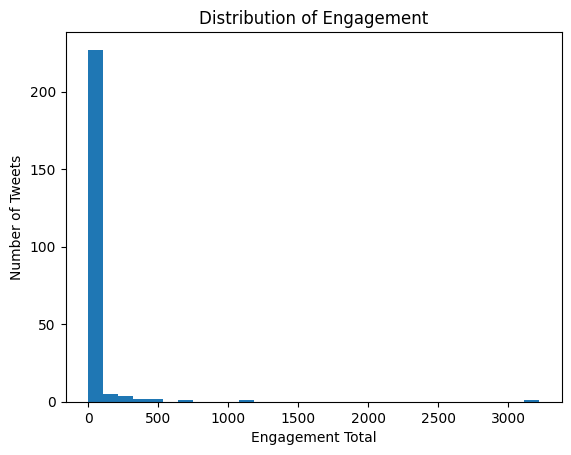

In [14]:

print(tweets_df[['engagement_total']].mean())
print(len(tweets_df))
print(tweets_df["engagement_total"].describe())

import matplotlib.pyplot as plt

plt.hist(tweets_df["engagement_total"], bins=30)
plt.xlabel("Engagement Total")
plt.ylabel("Number of Tweets")
plt.title("Distribution of Engagement")
plt.show()

In [15]:
print("Tweets:", len(tweets_df))
print("Media:", len(media_df))
print("Users:", len(users_df))

print("Duplicate tweets:", tweets_df["tweet_id"].duplicated().sum())
print("Duplicate media:", media_df["media_key"].duplicated().sum() if len(media_df) > 0 else 0)
print("Duplicate users:", users_df["author_id"].duplicated().sum() if len(users_df) > 0 else 0)

print(tweets_df["engagement_total"].describe())

Tweets: 243
Media: 94
Users: 231
Duplicate tweets: 0
Duplicate media: 0
Duplicate users: 0
count     243.000000
mean       39.699588
std       229.947057
min         0.000000
25%         0.000000
50%         1.000000
75%         5.500000
max      3221.000000
Name: engagement_total, dtype: float64


In [16]:
# Verifying correct data structure before SQL insertion
print("tweets_df:", tweets_df.shape)
print("media_df:", media_df.shape)
print("users_df:", users_df.shape)

print("Tweet columns:")
print(tweets_df.columns.tolist())

print("Media columns:")
print(media_df.columns.tolist())

print("User columns:")
print(users_df.columns.tolist())

tweets_df: (243, 19)
media_df: (94, 12)
users_df: (231, 10)
Tweet columns:
['tweet_id', 'author_id', 'created_at', 'text', 'clean_text', 'lang', 'retweet_count', 'reply_count', 'like_count', 'quote_count', 'has_media', 'media_count', 'collection_source', 'search_query', 'start_time_window', 'end_time_window', 'raw_json', 'engagement_total', 'eligible_for_labeling']
Media columns:
['media_key', 'tweet_id', 'media_type', 'url', 'preview_image_url', 'alt_text', 'width', 'height', 'duration_ms', 'public_metrics', 'raw_json', 'eligible_for_labeling']
User columns:
['author_id', 'username', 'name', 'verified', 'followers_count', 'following_count', 'tweet_count', 'listed_count', 'raw_json', 'eligible_for_labeling']


In [42]:
import numpy as np
import pandas as pd
import math

# Create SQL-ready copies
tweets_sql_df = tweets_df.drop(
    columns=["start_time_window", "end_time_window", "engagement_total"],
    errors="ignore"
).copy()

media_sql_df = media_df.copy()
users_sql_df = users_df.copy()

# Replace NaN / NA / NaT with None across all DataFrames
tweets_sql_df = tweets_sql_df.where(pd.notnull(tweets_sql_df), None)
media_sql_df = media_sql_df.where(pd.notnull(media_sql_df), None)
users_sql_df = users_sql_df.where(pd.notnull(users_sql_df), None)

# Convert media numeric fields to SQL-friendly integers or None
for col in ["width", "height", "duration_ms"]:
    if col in media_sql_df.columns:
        media_sql_df[col] = media_sql_df[col].apply(
            lambda x: None if x is None or pd.isna(x) else int(x)
        )
        media_sql_df[col] = media_sql_df[col].astype(object)
        media_sql_df[col] = media_sql_df[col].where(pd.notnull(media_sql_df[col]), None)

# Convert user numeric fields to SQL-friendly integers or None
for col in [
    "followers_count",
    "following_count",
    "tweet_count",
    "listed_count",
    "user_like_count",
    "user_media_count"
]:
    if col in users_sql_df.columns:
        users_sql_df[col] = users_sql_df[col].apply(
            lambda x: None if x is None or pd.isna(x) else int(x)
        )
        users_sql_df[col] = users_sql_df[col].astype(object)
        users_sql_df[col] = users_sql_df[col].where(pd.notnull(users_sql_df[col]), None)

# Final hard cleanup before SQL insert
tweets_records = tweets_sql_df.to_dict(orient="records")
media_records = media_sql_df.to_dict(orient="records")
users_records = users_sql_df.to_dict(orient="records")

def clean_record(record):
    return {
        key: (None if isinstance(value, float) and math.isnan(value) else value)
        for key, value in record.items()
    }

tweets_records = [clean_record(r) for r in tweets_records]
media_records = [clean_record(r) for r in media_records]
users_records = [clean_record(r) for r in users_records]

In [39]:
# Defining SQL Insertion functions
from sqlalchemy import text

insert_users_sql = text("""
INSERT INTO users (
    author_id, username, name, verified,
    followers_count, following_count, tweet_count, listed_count,
    eligible_for_labeling,
    raw_json
)
VALUES (
    :author_id, :username, :name, :verified,
    :followers_count, :following_count, :tweet_count, :listed_count,
    :eligible_for_labeling,
    CAST(:raw_json AS JSONB)
)
ON CONFLICT (author_id) DO UPDATE SET
    username = EXCLUDED.username,
    name = EXCLUDED.name,
    verified = EXCLUDED.verified,
    followers_count = EXCLUDED.followers_count,
    following_count = EXCLUDED.following_count,
    tweet_count = EXCLUDED.tweet_count,
    listed_count = EXCLUDED.listed_count,
    eligible_for_labeling = EXCLUDED.eligible_for_labeling,
    raw_json = EXCLUDED.raw_json;
""")

insert_tweets_sql = text("""
INSERT INTO tweets (
    tweet_id, author_id, created_at, text, clean_text, lang,
    retweet_count, reply_count, like_count, quote_count,
    has_media, media_count,
    collection_source, search_query,
    eligible_for_labeling,
    raw_json
)
VALUES (
    :tweet_id, :author_id, :created_at, :text, :clean_text, :lang,
    :retweet_count, :reply_count, :like_count, :quote_count,
    :has_media, :media_count,
    :collection_source, :search_query,
    :eligible_for_labeling,
    CAST(:raw_json AS JSONB)
)
ON CONFLICT (tweet_id) DO UPDATE SET
    retweet_count = EXCLUDED.retweet_count,
    reply_count = EXCLUDED.reply_count,
    like_count = EXCLUDED.like_count,
    quote_count = EXCLUDED.quote_count,
    has_media = EXCLUDED.has_media,
    media_count = EXCLUDED.media_count,
    collection_source = EXCLUDED.collection_source,
    search_query = EXCLUDED.search_query,
    eligible_for_labeling = EXCLUDED.eligible_for_labeling,
    raw_json = EXCLUDED.raw_json;
""")

insert_media_sql = text("""
INSERT INTO tweet_media (
    media_key, tweet_id, media_type, url, preview_image_url,
    alt_text, width, height, duration_ms,
    public_metrics,
    eligible_for_labeling,
    raw_json
)
VALUES (
    :media_key, :tweet_id, :media_type, :url, :preview_image_url,
    :alt_text, :width, :height, :duration_ms,
    CAST(:public_metrics AS JSONB),
    :eligible_for_labeling,
    CAST(:raw_json AS JSONB)
)
ON CONFLICT (media_key) DO UPDATE SET
    media_type = EXCLUDED.media_type,
    url = EXCLUDED.url,
    preview_image_url = EXCLUDED.preview_image_url,
    alt_text = EXCLUDED.alt_text,
    width = EXCLUDED.width,
    height = EXCLUDED.height,
    duration_ms = EXCLUDED.duration_ms,
    public_metrics = EXCLUDED.public_metrics,
    eligible_for_labeling = EXCLUDED.eligible_for_labeling,
    raw_json = EXCLUDED.raw_json;
""")

In [43]:
# SQL Insertion
with engine.begin() as conn:
    if len(users_records) > 0:
        conn.execute(insert_users_sql, users_records)

    if len(tweets_records) > 0:
        conn.execute(insert_tweets_sql, tweets_records)

    if len(media_records) > 0:
        conn.execute(insert_media_sql, media_records)

print("Inserted/updated users:", len(users_records))
print("Inserted/updated tweets:", len(tweets_records))
print("Inserted/updated media:", len(media_records))

Inserted/updated users: 231
Inserted/updated tweets: 243
Inserted/updated media: 94


In [44]:
with engine.connect() as conn:
    print("Tweets:", conn.execute(text("SELECT COUNT(*) FROM tweets;")).scalar())
    print("Media:", conn.execute(text("SELECT COUNT(*) FROM tweet_media;")).scalar())
    print("Users:", conn.execute(text("SELECT COUNT(*) FROM users;")).scalar())
    print("Eligible tweets:", conn.execute(text("SELECT COUNT(*) FROM tweets WHERE eligible_for_labeling = TRUE;")).scalar())

Tweets: 243
Media: 94
Users: 231
Eligible tweets: 121


# Step 2: Full Automated Data Colleciton

In [45]:
# New timeframes and queries
time_windows = [
    (7.0, 6.0),
    (6.0, 5.0),
    (5.0, 4.0),
    (4.0, 3.0),
    (3.0, 2.0)
]

queries = [
    # Broad baseline
    {"name": "broad_general_1", "text": '("the" OR "this" OR "that" OR "with") lang:en -is:retweet'},
    {"name": "broad_general_2", "text": '("good" OR "people" OR "today" OR "day") lang:en -is:retweet'},
    {"name": "broad_general_3", "text": '("look" OR "think" OR "know" OR "feel") lang:en -is:retweet'},

    # Engagement-style candidates
    {"name": "engagement_reply", "text": '("reply below" OR "comment below" OR "drop your" OR "tell me") lang:en -is:retweet'},
    {"name": "engagement_share", "text": '("like this" OR "share this" OR "retweet this" OR "follow me") lang:en -is:retweet'},
    {"name": "engagement_tag", "text": '("tag someone" OR "tag a friend" OR "send this to" OR "who needs this") lang:en -is:retweet'},
    {"name": "engagement_grok", "text": '("@grok" OR "Grok explain" OR "ask Grok") lang:en -is:retweet'},
    {"name": "engagement_identity", "text": '("Full Name:" OR "Real Name:" OR "Age:" OR "Location:") lang:en -is:retweet'},

    # Clickbait / urgency
    {"name": "clickbait_news", "text": '("NEW:" OR "BREAKING:" OR "DEVELOPING:" OR "JUST IN:") lang:en -is:retweet'},
    {"name": "clickbait_emotional", "text": '("INSANE" OR "SHOCKING" OR "EXPOSED" OR "WOW") lang:en -is:retweet'},
    {"name": "emoji_urgency", "text": '("🚨" OR "🔥" OR "‼️" OR "💀") lang:en -is:retweet'},

    # Topic variety
    {"name": "sports_general", "text": '(score OR win OR lose OR stats OR game) lang:en -is:retweet'},
    {"name": "technology_general", "text": '(AI OR tech OR software OR iPhone OR Android OR data OR code OR app) lang:en -is:retweet'},
    {"name": "entertainment_general", "text": '("movie" OR "music" OR "game" OR "show" OR "book" OR "film") lang:en -is:retweet'},

    # Political/current events, useful for rage-bait/clickbait detection
    {"name": "political_general_1", "text": '("Trump" OR "Biden" OR "Republican" OR "Democrat") lang:en -is:retweet'},
    {"name": "political_general_2", "text": '("election" OR "policy" OR "Left" OR "Right" OR "Liberal" OR "Conservative") lang:en -is:retweet'},
]

In [ ]:
# Full data collection
full_responses = []

now = datetime.now(timezone.utc)

for query in queries:
    query_name = query["name"]
    query_text = query["text"]

    for start_days, end_days in time_windows:
        start_time = now - timedelta(days=start_days)
        end_time = now - timedelta(days=end_days)

        start_time_str = start_time.isoformat(timespec="seconds").replace("+00:00", "Z")
        end_time_str = end_time.isoformat(timespec="seconds").replace("+00:00", "Z")

        response = client.search_recent_tweets(
            query=query_text,
            max_results=100,
            start_time=start_time_str,
            end_time=end_time_str,
            sort_order="relevancy",
            tweet_fields=[
                "created_at", "author_id", "lang", "public_metrics",
                "entities", "attachments", "referenced_tweets"
            ],
            expansions=[
                "attachments.media_keys",
                "author_id"
            ],
            media_fields=[
                "media_key", "type", "url", "preview_image_url",
                "alt_text", "width", "height", "duration_ms", "public_metrics"
            ],
            user_fields=[
                "username", "name", "verified", "public_metrics"
            ]
        )

        tweet_count = 0 if response.data is None else len(response.data)

        print(f"{query_name} | {start_time_str} to {end_time_str} | tweets returned: {tweet_count}")

        full_responses.append({
            "query_name": query_name,
            "query_text": query_text,
            "start_time": start_time_str,
            "end_time": end_time_str,
            "response": response,
            "tweet_count": tweet_count
        })

print("Total API calls made:", len(full_responses))
print("Total tweets returned before deduping:", sum(r["tweet_count"] for r in full_responses))

broad_general_1 | 2026-06-05T19:40:42Z to 2026-06-06T19:40:42Z | tweets returned: 97
broad_general_1 | 2026-06-06T19:40:42Z to 2026-06-07T19:40:42Z | tweets returned: 93
broad_general_1 | 2026-06-07T19:40:42Z to 2026-06-08T19:40:42Z | tweets returned: 94
broad_general_1 | 2026-06-08T19:40:42Z to 2026-06-09T19:40:42Z | tweets returned: 99
broad_general_1 | 2026-06-09T19:40:42Z to 2026-06-10T19:40:42Z | tweets returned: 96
broad_general_2 | 2026-06-05T19:40:42Z to 2026-06-06T19:40:42Z | tweets returned: 96
broad_general_2 | 2026-06-06T19:40:42Z to 2026-06-07T19:40:42Z | tweets returned: 91
broad_general_2 | 2026-06-07T19:40:42Z to 2026-06-08T19:40:42Z | tweets returned: 100
broad_general_2 | 2026-06-08T19:40:42Z to 2026-06-09T19:40:42Z | tweets returned: 99
broad_general_2 | 2026-06-09T19:40:42Z to 2026-06-10T19:40:42Z | tweets returned: 98
broad_general_3 | 2026-06-05T19:40:42Z to 2026-06-06T19:40:42Z | tweets returned: 91
broad_general_3 | 2026-06-06T19:40:42Z to 2026-06-07T19:40:42Z |

In [47]:
# Full collection variety check

full_rows = []

for item in full_responses:
    response = item["response"]

    for tweet in response.data or []:
        metrics = tweet.public_metrics or {}

        full_rows.append({
            "tweet_id": str(tweet.id),
            "query_name": item["query_name"],
            "start_time_window": item["start_time"],
            "end_time_window": item["end_time"],
            "created_at": tweet.created_at,
            "text": tweet.text,
            "like_count": metrics.get("like_count", 0),
            "reply_count": metrics.get("reply_count", 0),
            "retweet_count": metrics.get("retweet_count", 0),
            "quote_count": metrics.get("quote_count", 0),
        })

full_df = pd.DataFrame(full_rows)

full_df["engagement_total"] = (
    full_df["like_count"] +
    full_df["reply_count"] +
    full_df["retweet_count"] +
    full_df["quote_count"]
)

full_df = full_df.drop_duplicates(subset="tweet_id")

print("Unique tweets:", len(full_df))
print("Unique queries represented:", full_df["query_name"].nunique())
print("Created_at range:", full_df["created_at"].min(), "to", full_df["created_at"].max())

display(
    full_df[[
        "query_name",
        "created_at",
        "like_count",
        "reply_count",
        "retweet_count",
        "quote_count",
        "engagement_total",
        "text"
    ]]
    .sort_values("engagement_total", ascending=False)
    .head(25)
)

Unique tweets: 7587
Unique queries represented: 16
Created_at range: 2026-06-05 19:41:58+00:00 to 2026-06-10 19:38:47+00:00


,query_name,created_at,like_count,reply_count,retweet_count,quote_count,engagement_total,text
295,broad_general_1,2026-06-09 01:12:33+00:00,19924,2068,968,85,23045,14 year old arrested for assaulting a teacher ...
1579,engagement_reply,2026-06-06 20:54:55+00:00,9217,118,1702,2,11039,Black fishnets + maximum exposure 🔥\nTell me y...
7258,political_general_2,2026-06-07 17:14:53+00:00,8315,204,848,36,9403,Karen Bass rigged the election in Los Angeles ...
1409,broad_general_3,2026-06-10 19:24:45+00:00,7155,396,467,39,8057,I know a setup like this for many people would...
431,broad_general_1,2026-06-09 23:02:46+00:00,5906,143,858,24,6931,"@zarahussain999 .@zarahussain999, the far righ..."
1709,engagement_reply,2026-06-08 10:33:12+00:00,4668,317,857,34,5876,"That receipt was from 2020, right? That was wh..."
4401,clickbait_emotional,2026-06-06 22:49:58+00:00,4603,21,136,14,4774,no but fr getting exposed for fucking your cou...
2213,engagement_share,2026-06-09 15:23:41+00:00,1336,101,2362,28,3827,Skenes Night: He’s due. So here’s the deal. If...
3953,clickbait_news,2026-06-07 20:55:03+00:00,2801,217,692,29,3739,"🚨JUST IN: U.S. Military on ""HIGH ALERT""\n\nPre..."
1010,broad_general_3,2026-06-06 12:17:39+00:00,2601,6,771,110,3488,💬 what do you think about people being judgy\n...


In [48]:
# Full DataFrame creation from multiple query/time-window responses

full_tweet_rows = []
full_media_rows = []
full_user_rows = []

for item in full_responses:
    response = item["response"]
    query_name = item["query_name"]
    query_text = item["query_text"]
    start_time_window = item["start_time"]
    end_time_window = item["end_time"]

    tweets = response.data or []
    includes = response.includes or {}

    media_lookup = {
        media.data["media_key"]: media
        for media in includes.get("media", [])
    }

    # users
    for user in includes.get("users", []):
        metrics = user.data.get("public_metrics", {})

        full_user_rows.append({
            "author_id": str(user.id),
            "username": user.data.get("username"),
            "name": user.data.get("name"),
            "verified": user.data.get("verified"),
            "followers_count": metrics.get("followers_count", 0),
            "following_count": metrics.get("following_count", 0),
            "tweet_count": metrics.get("tweet_count", 0),
            "listed_count": metrics.get("listed_count", 0),
            "raw_json": json.dumps(user.data)
        })

    # tweets and media
    for tweet in tweets:
        metrics = tweet.public_metrics or {}
        attachments = tweet.data.get("attachments", {})
        media_keys = attachments.get("media_keys", [])

        full_tweet_rows.append({
            "tweet_id": str(tweet.id),
            "author_id": str(tweet.author_id),
            "created_at": tweet.created_at,
            "text": tweet.text,
            "clean_text": clean_tweet_text(tweet.text),
            "lang": tweet.lang,

            "retweet_count": metrics.get("retweet_count", 0),
            "reply_count": metrics.get("reply_count", 0),
            "like_count": metrics.get("like_count", 0),
            "quote_count": metrics.get("quote_count", 0),

            "has_media": len(media_keys) > 0,
            "media_count": len(media_keys),

            "collection_source": query_name,
            "search_query": query_text,

            # useful for testing; not currently in your database unless you add columns
            "start_time_window": start_time_window,
            "end_time_window": end_time_window,

            "raw_json": json.dumps(tweet.data)
        })

        for media_key in media_keys:
            media = media_lookup.get(media_key)

            if media is None:
                continue

            full_media_rows.append({
                "media_key": media_key,
                "tweet_id": str(tweet.id),
                "media_type": media.data.get("type"),
                "url": media.data.get("url"),
                "preview_image_url": media.data.get("preview_image_url"),
                "alt_text": media.data.get("alt_text"),
                "width": media.data.get("width"),
                "height": media.data.get("height"),
                "duration_ms": media.data.get("duration_ms"),
                "public_metrics": json.dumps(media.data.get("public_metrics", {})),
                "raw_json": json.dumps(media.data)
            })

full_tweets_df = pd.DataFrame(full_tweet_rows)
full_media_df = pd.DataFrame(full_media_rows)
full_users_df = pd.DataFrame(full_user_rows)

# Deduplicate
if len(full_tweets_df) > 0:
    full_tweets_df = full_tweets_df.drop_duplicates(subset="tweet_id").copy()

if len(full_media_df) > 0:
    full_media_df = full_media_df.drop_duplicates(subset="media_key").copy()

if len(full_users_df) > 0:
    full_users_df = full_users_df.drop_duplicates(subset="author_id").copy()

# Engagement features
if len(full_tweets_df) > 0:
    full_tweets_df["engagement_total"] = (
        full_tweets_df["like_count"] +
        full_tweets_df["reply_count"] +
        full_tweets_df["retweet_count"] +
        full_tweets_df["quote_count"]
    )

    full_tweets_df = full_tweets_df.sort_values(by="engagement_total", ascending=False)



full_tweets_df["eligible_for_labeling"] = (
    full_tweets_df["engagement_total"] >= 2
)

# Propagate eligible_for_labeling to media_df and users_df
tweet_eligibility_lookup = (
    full_tweets_df
    .set_index("tweet_id")["eligible_for_labeling"]
    .to_dict()
)

user_eligibility_lookup = (
    full_tweets_df
    .groupby("author_id")["eligible_for_labeling"]
    .any()
    .to_dict()
)

if len(full_media_df) > 0:
    full_media_df["eligible_for_labeling"] = (
        full_media_df["tweet_id"]
        .map(tweet_eligibility_lookup)
        .fillna(False)
    )
else:
    full_media_df["eligible_for_labeling"] = pd.Series(dtype=bool)

if len(full_users_df) > 0:
    full_users_df["eligible_for_labeling"] = (
        full_users_df["author_id"]
        .map(user_eligibility_lookup)
        .fillna(False)
    )
else:
    full_users_df["eligible_for_labeling"] = pd.Series(dtype=bool)

display(full_tweets_df.head())
display(full_media_df.head())
display(full_users_df.head())

,tweet_id,author_id,created_at,text,clean_text,lang,retweet_count,reply_count,like_count,quote_count,has_media,media_count,collection_source,search_query,start_time_window,end_time_window,raw_json,engagement_total,eligible_for_labeling
295,2064153642915991998,1893606127834738688,2026-06-09 01:12:33+00:00,14 year old arrested for assaulting a teacher ...,14 year old arrested for assaulting a teacher ...,en,968,2068,19924,85,True,1,broad_general_1,"(""the"" OR ""this"" OR ""that"" OR ""with"") lang:en ...",2026-06-08T19:40:42Z,2026-06-09T19:40:42Z,"{""public_metrics"": {""retweet_count"": 968, ""rep...",23045,True
1579,2063364032984183224,1784282989188304897,2026-06-06 20:54:55+00:00,Black fishnets + maximum exposure 🔥\nTell me y...,Black fishnets + maximum exposure 🔥 Tell me yo...,en,1702,118,9217,2,True,3,engagement_reply,"(""reply below"" OR ""comment below"" OR ""drop you...",2026-06-06T19:40:42Z,2026-06-07T19:40:42Z,"{""entities"": {""urls"": [{""start"": 164, ""end"": 1...",11039,True
7258,2063671047186952416,859409582426251269,2026-06-07 17:14:53+00:00,Karen Bass rigged the election in Los Angeles ...,Karen Bass rigged the election in Los Angeles ...,en,848,204,8315,36,False,0,political_general_2,"(""election"" OR ""policy"" OR ""Left"" OR ""Right"" O...",2026-06-06T19:40:42Z,2026-06-07T19:40:42Z,"{""entities"": {""urls"": [{""start"": 269, ""end"": 2...",9403,True
1409,2064790891584196874,443679402,2026-06-10 19:24:45+00:00,I know a setup like this for many people would...,I know a setup like this for many people would...,en,467,396,7155,39,True,1,broad_general_3,"(""look"" OR ""think"" OR ""know"" OR ""feel"") lang:e...",2026-06-09T19:40:42Z,2026-06-10T19:40:42Z,"{""created_at"": ""2026-06-10T19:24:45.000Z"", ""au...",8057,True
431,2064483372609503583,1777721859431174144,2026-06-09 23:02:46+00:00,"@zarahussain999 .@zarahussain999, the far righ...","@USER .@USER, the far right card. Every time. ...",en,858,143,5906,24,False,0,broad_general_1,"(""the"" OR ""this"" OR ""that"" OR ""with"") lang:en ...",2026-06-09T19:40:42Z,2026-06-10T19:40:42Z,"{""created_at"": ""2026-06-09T23:02:46.000Z"", ""au...",6931,True


,media_key,tweet_id,media_type,url,preview_image_url,alt_text,width,height,duration_ms,public_metrics,raw_json,eligible_for_labeling
0,3_2063022446656020480,2063022448841486522,photo,https://pbs.twimg.com/media/HKFT_CCW4AAKo5W.jpg,NaN,NaN,695,518,NaN,{},"{""media_key"": ""3_2063022446656020480"", ""url"": ...",True
1,3_2063191132478042112,2063198338170646861,photo,https://pbs.twimg.com/media/HKHtZ1sW8AAGQQT.jpg,NaN,NaN,1148,2048,NaN,{},"{""media_key"": ""3_2063191132478042112"", ""url"": ...",True
2,3_2063191132419260416,2063198338170646861,photo,https://pbs.twimg.com/media/HKHtZ1eWAAAAl9k.jpg,NaN,NaN,1179,2008,NaN,{},"{""media_key"": ""3_2063191132419260416"", ""url"": ...",True
3,3_2063191132431937538,2063198338170646861,photo,https://pbs.twimg.com/media/HKHtZ1hXcAI8PMw.jpg,NaN,NaN,2048,1228,NaN,{},"{""media_key"": ""3_2063191132431937538"", ""url"": ...",True
4,13_2063115126170165248,2063115263021916388,video,NaN,https://pbs.twimg.com/amplify_video_thumb/2063...,NaN,1276,720,30045.0,"{""view_count"": 1}","{""media_key"": ""13_2063115126170165248"", ""durat...",False


,author_id,username,name,verified,followers_count,following_count,tweet_count,listed_count,raw_json,eligible_for_labeling
0,1999888236056035328,RandomUser506,"Human, Sarcastic (1 ea.)",False,187,298,3662,5,"{""public_metrics"": {""followers_count"": 187, ""f...",False
1,1498291581161381895,Uilium,Togetherness,False,420,576,11056,6,"{""public_metrics"": {""followers_count"": 420, ""f...",False
2,2983167412,melsmatchat,👑👸🏻MELISSA A. KLEIN👸🏻👑 (🫦MEL'S MAT CHAT🫦),False,1356,1627,86956,17,"{""public_metrics"": {""followers_count"": 1356, ""...",False
3,1207007521485049856,Phillip33528717,Christ is the bread 🍞 and the wine 🍷,False,655,763,43587,7,"{""public_metrics"": {""followers_count"": 655, ""f...",True
4,1719166753043791872,trumps_kitten,AmericaUncensored,False,5503,1702,41422,40,"{""public_metrics"": {""followers_count"": 5503, ""...",True


In [ ]:
# Cleaning dataframes for SQL insertion
full_tweets_sql_df = full_tweets_df.drop(
    columns=["start_time_window", "end_time_window", "engagement_total"],
    errors="ignore"
).copy()

full_media_sql_df = full_media_df.copy()
full_users_sql_df = full_users_df.copy()

full_tweets_sql_df = full_tweets_sql_df.where(pd.notnull(full_tweets_sql_df), None)
full_media_sql_df = full_media_sql_df.where(pd.notnull(full_media_sql_df), None)
full_users_sql_df = full_users_sql_df.where(pd.notnull(full_users_sql_df), None)

full_tweets_records = full_tweets_sql_df.to_dict(orient="records")
full_media_records = full_media_sql_df.to_dict(orient="records")
full_users_records = full_users_sql_df.to_dict(orient="records")

import math

def clean_record(record):
    return {
        k: None if isinstance(v, float) and math.isnan(v) else v
        for k, v in record.items()
    }

full_tweets_records = [clean_record(r) for r in full_tweets_records]
full_media_records = [clean_record(r) for r in full_media_records]
full_users_records = [clean_record(r) for r in full_users_records]

In [50]:
# SQL Insertion
with engine.begin() as conn:
    if len(full_users_records) > 0:
        conn.execute(insert_users_sql, full_users_records)

    if len(full_tweets_records) > 0:
        conn.execute(insert_tweets_sql, full_tweets_records)

    if len(full_media_records) > 0:
        conn.execute(insert_media_sql, full_media_records)

print("Inserted/updated users:", len(full_users_records))
print("Inserted/updated tweets:", len(full_tweets_records))
print("Inserted/updated media:", len(full_media_records))

Inserted/updated users: 5745
Inserted/updated tweets: 7587
Inserted/updated media: 3075


# Step 3: Building the Labeler Using OpenAI API

In [ ]:
# SQL Join Query to join our 3 tables into one for labeling preparation
labeling_query = """
SELECT
    t.tweet_id,
    t.text,
    t.clean_text,
    t.created_at,
    t.has_media,
    t.media_count,
    t.collection_source,
    t.search_query,
    t.like_count,
    t.reply_count,
    t.retweet_count,
    t.quote_count,

    u.username,
    u.name,
    u.verified,
    u.followers_count,
    u.following_count,
    u.tweet_count AS user_tweet_count,
    u.listed_count,

    m.media_key,
    m.media_type,
    m.url,
    m.preview_image_url,
    m.alt_text,
    m.width,
    m.height,
    m.duration_ms,
    m.public_metrics AS media_public_metrics

FROM tweets t
LEFT JOIN users u
    ON t.author_id = u.author_id
LEFT JOIN tweet_media m
    ON t.tweet_id = m.tweet_id
LEFT JOIN tweet_labels l
    ON t.tweet_id = l.tweet_id
WHERE t.eligible_for_labeling = TRUE
  AND l.tweet_id IS NULL
ORDER BY t.tweet_id;"""

labeling_df = pd.read_sql(labeling_query, engine)


In [6]:
# Sumamry stats for our full data
print("Rows:", len(labeling_df))
print("Unique tweets:", labeling_df["tweet_id"].nunique())
print("Unique media:", labeling_df["media_key"].nunique())

media_counts = (
    labeling_df
    .groupby("tweet_id")
    .size()
    .value_counts()
    .sort_index()
)

print(media_counts)

Rows: 3969
Unique tweets: 3358
Unique media: 2040
1    3038
2     151
3      47
4     122
Name: count, dtype: int64


In [7]:
# Grouping to ensure tweets with multiple media are properly represented

all_packages = []

for tweet_id, group in labeling_df.groupby("tweet_id"):

    tweet_info = group.iloc[0]

    media_items = []

    for _, row in group.iterrows():

        if pd.notna(row["media_key"]):

            media_items.append({
                "media_type": row["media_type"],
                "url": row["url"],
                "preview_image_url": row["preview_image_url"],
                "alt_text": row["alt_text"]
            })

    tweet_package = {
        "tweet_id": tweet_id,
        "text": tweet_info["text"],
        "username": tweet_info["username"],
        "verified": bool(tweet_info["verified"]),
        "followers_count": int(tweet_info["followers_count"]),
        "engagement": {
    "likes": row["like_count"],
    "replies": row["reply_count"],
    "retweets": row["retweet_count"],
    "quotes": row["quote_count"]
    },
        "media": media_items
    }

    all_packages.append(tweet_package)

In [ ]:
# Example output of a single tweet package for verification

print(
    json.dumps(
        all_packages[2236],
        indent=2,
        default=str
    )
)

{
  "tweet_id": "2064217597231407403",
  "text": "Up and grateful. Good morning, my lovely people. \ud83c\udf1e\nA new day is here, filled with fresh opportunities, new blessings, and endless possibilities. May today bring you peace, joy, good health, and success in all that you do. Let's begin this day with gratitude and a positive https://t.co/dIajpoYJGq",
  "username": "Christine765627",
  "verified": false,
  "followers_count": 3964,
  "engagement": {
    "likes": 43,
    "replies": 19,
    "retweets": 20,
    "quotes": 0
  },
  "media": [
    {
      "media_type": "photo",
      "url": "https://pbs.twimg.com/media/HKWS9JAWMAAFvlS.jpg",
      "preview_image_url": NaN,
      "alt_text": NaN
    }
  ]
}


# Step 4: Labeling Tweets

In [ ]:
# Connecting to OpenAI API for labeling

load_dotenv()

openai_client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [ ]:
# Labeling prompt construction (FINAL RESULT, important rules to refine previous prompts)
def build_label_prompt(package):
    return f"""
You are labeling tweets for an engagement-bait classifier.

Classify the tweet into exactly one of these labels:

1. normal
- The tweet does not primarily ask for or engineer engagement.

2. benign_engagement_prompt
- The tweet encourages replies, likes, tagging, sharing, opinions, votes, or participation,
  but in a harmless, social, or community-oriented way.
- Pay close attention to language, context, and intent.
- An example would be someone tweeting about their birthday. While there might not be any
  explicit "like this if you wish me a happy birthday" text, the intent is to share a personal
  milestone and invite well-wishes, which is a normal and socially acceptable reason for engagement.

3. harmful_engagement_bait
- The tweet appears designed primarily to inflate engagement through misleading,
  coercive, spammy, sexual language/innuendos/media, sensationalism, rage-bait,
  curiosity gaps, fake urgency, all-caps clickbait, giveaway bait, fake news,
  outrage farming, or artificial interaction prompts.
- Examples include:
    * "LIKE IF YOU AGREE"
    * "ONLY REAL ONES KNOW"
    * "TAG SOMEONE WHO..."
    * Fake breaking news
    * Rage-bait political content
    * Sexualized engagement farming
    * Provocative questions designed primarily to drive replies

Important rules:

- Judge the tweet's wording, intent, and available media context.
- Do not label something manipulative only because it received many likes.
- Engagement metrics may provide context, but should not determine the label.
- If the tweet asks people to reply/like/share in a harmless way, use benign_engagement_prompt.
- If the tweet uses deception, fake urgency, rage bait, clickbait, or spam tactics,
  use harmful_engagement_bait.
- If unsure between benign and harmful, choose the less severe label and lower confidence.
- Focus on the PRIMARY intent of the tweet.
- Not all engagement-seeking behavior is manipulative.
- Political opinions alone are NOT engagement bait, but if strong language and/or sarcastic phrasing is used to provoke outrage or controversy, it may be bait.
- Religious content alone is NOT engagement bait.
- Personal updates alone are NOT engagement bait.
- Humor alone is NOT engagement bait.
- A tweet may be controversial without being engagement bait.
- Capitalization is important to consider, especially if controversial language is capitalized (eg curse words, political terms, etc.). Capitalization draws attention, which can be an indicator of bait when combined with controversial or provocative language.
- Pay close attention to word choice, strong language is a common tactic for engagement bait, placing more weight towards harmful on tweets with curse words or sexual content.
- context outweighs curse words in terms of classification in tweets containing both curse words and context that is clearly benign (eg a personal frustration or a humorous tweet)
- any tweet that asks or is phrased like a question is typically bait, but more likely than not benign rather than harmful
- tweets with multiple @s at the beggining (indicating a larger conversation), could be a good indicator of engagement type
- use context clues to distinguish between a tweet expressing personal frustration using strong language and a tweet that is phrased to provoke outrage or controversy for the sake of engagement
- overrated/underrated are common keywords for engagement bait, also typically benign rather than harmful in contexts like sports or media (movies, players, etc.)
- tweets that are replies that express negative emotions or potential bait indicators might not be bait, and just a passionate response to a previous tweet, so consider the context of the conversation and the language used in the reply if they are trying to engage others in a 2 person conversation or if they are trying to provoke engagement from a wider audience
- tweets with a lot of emojis or hashtages are typically bait, but are much more likely than not benign rather than harmful.
- reply farming tweets should be classified as benign unless they are using manipulative or aggressive tactics to provoke outrage or controversy for the sake of engagement (eg asking opinions)
- if a tweet mentions blocking, reporting, lying or another negative action as a reply to someone else, it is most likely harmful bait
- tweets with indented/separated text are typically that way in order to draw attention, most likely harmless, but still potentially bait (use context clues to determine if the tweet is benign or harmful)
- tweets clearly targeted to a single individual are not bait, but if they are phrased in a way to provoke engagement from a wider audience, they are likely bait
- if 2 tweets have very similar content, structure, and word choices, label them similarly (eg language, subject, indentation, emojis, hashtags, etc.)

MOST IMPORANT NOTE:
- Make sure each tweet that is labeled with either benign or harmful bait has both an engagement_label and a bait_type. If the tweet is labeled as normal, the bait_type should be "none".




The tweet data is provided as a package.

The package contains:

- tweet information
- user/account information
- engagement metrics
- a list of all media attached to the tweet

If multiple media objects exist, consider ALL of them when making your decision.

Media metadata may contain:
- media_type
- image URLs
- preview image URLs
- alt text
- dimensions
- duration

Use media information only as supporting context.

Tweet Package:

{json.dumps(package, indent=2, default=str)}

Return ONLY valid JSON in exactly this format:

{{
  "tweet_id": "{package['tweet_id']}",
  "engagement_label": "normal | benign_engagement_prompt | harmful_engagement_bait",
  "is_engagement_bait": true,
  "is_harmful_bait": false,
  "label_confidence": 0.0,
  "bait_type": "none | harmless_prompt | reply_farming | like_farming | tag_farming | share_farming | giveaway_bait | clickbait | rage_bait | curiosity_gap | fake_urgency | misinformation_hook | sexual_engagement_bait | outrage_farming | other",
  "media_context_used": false,
  "label_reason": "brief explanation"
}}

Return JSON only. Do not include markdown. Do not include explanations outside the JSON.
"""

In [19]:
# Labeler
def label_tweet_package(package, model="gpt-4o-mini"):
    prompt = build_label_prompt(package)

    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": "You are a careful data labeling assistant. Return only valid JSON."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    content = response.choices[0].message.content.strip()

    try:
        label = json.loads(content)
    except json.JSONDecodeError:
        print("JSON parse failed for tweet:", package["tweet_id"])
        print(content)
        return None

    return label

In [13]:
# Test on 10 tweets first
test_packages = all_packages[:10]

test_results = []

for i, package in enumerate(test_packages, start=1):
    print(f"Labeling {i}/{len(test_packages)} | tweet_id={package['tweet_id']}")

    result = label_tweet_package(package)

    if result is not None:
        test_results.append(result)

test_labels_df = pd.DataFrame(test_results)



Labeling 1/10 | tweet_id=2062610462270017698
Labeling 2/10 | tweet_id=2062611031377969203
Labeling 3/10 | tweet_id=2062611385218158838
Labeling 4/10 | tweet_id=2062611417493086518
Labeling 5/10 | tweet_id=2062613174629658687
Labeling 6/10 | tweet_id=2062614676660187382
Labeling 7/10 | tweet_id=2062614681760509965
Labeling 8/10 | tweet_id=2062618866895720802
Labeling 9/10 | tweet_id=2062619708227223672
Labeling 10/10 | tweet_id=2062626180042301847


In [14]:
# Build lookup from package -> text
tweet_lookup = {
    p["tweet_id"]: p["text"]
    for p in all_packages
}

# Add original tweet text
test_labels_df["tweet_text"] = (
    test_labels_df["tweet_id"]
    .map(tweet_lookup)
)

display(
    test_labels_df[[
        "tweet_id",
        "tweet_text",
        "engagement_label",
        "is_engagement_bait",
        "is_manipulative_bait",
        "label_confidence",
        "bait_type",
        "label_reason"
    ]]
)
test_labels_df

,tweet_id,tweet_text,engagement_label,is_engagement_bait,is_manipulative_bait,label_confidence,bait_type,label_reason
0,2062610462270017698,"@yogurtlover02 play a game, start a new show/m...",normal,False,False,1.0,none,The tweet shares personal activities without s...
1,2062611031377969203,@donkas101 @korkodiaING @fatiscoproduct @KelOn...,normal,False,False,1.0,none,The tweet expresses frustration about loans an...
2,2062611385218158838,My agent engineering hacks (inspired by @mvanh...,normal,False,False,1.0,none,The tweet shares technical advice and insights...
3,2062611417493086518,@ChrisMartzWX I actually think Queen are under...,normal,False,False,1.0,none,The tweet expresses a personal opinion about m...
4,2062613174629658687,@swirlixpolls 1) Grandad used to do the best g...,normal,False,False,1.0,none,The tweet shares personal opinions and experie...
5,2062614676660187382,What fast food spot did you work at? I worked ...,benign_engagement_prompt,True,False,0.8,harmless_prompt,The tweet invites others to share their experi...
6,2062614681760509965,taylor swift’s\n\nbest song: all too well 10 m...,normal,False,False,1.0,none,The tweet shares personal opinions about Taylo...
7,2062618866895720802,"@shagbark_hick I do what your friend did, chas...",normal,False,False,1.0,none,The tweet shares a personal experience without...
8,2062619708227223672,Best defender of the 2020s that just broke the...,normal,False,False,1.0,none,The tweet expresses an opinion about a sports ...
9,2062626180042301847,@GrimoireRodreg1 @hexag0n414 @friedluigi_real ...,manipulative_engagement_bait,True,True,0.9,rage_bait,The tweet expresses strong negative sentiments...


,tweet_id,engagement_label,is_engagement_bait,is_manipulative_bait,label_confidence,bait_type,media_context_used,label_reason,tweet_text
0,2062610462270017698,normal,False,False,1.0,none,False,The tweet shares personal activities without s...,"@yogurtlover02 play a game, start a new show/m..."
1,2062611031377969203,normal,False,False,1.0,none,False,The tweet expresses frustration about loans an...,@donkas101 @korkodiaING @fatiscoproduct @KelOn...
2,2062611385218158838,normal,False,False,1.0,none,False,The tweet shares technical advice and insights...,My agent engineering hacks (inspired by @mvanh...
3,2062611417493086518,normal,False,False,1.0,none,False,The tweet expresses a personal opinion about m...,@ChrisMartzWX I actually think Queen are under...
4,2062613174629658687,normal,False,False,1.0,none,False,The tweet shares personal opinions and experie...,@swirlixpolls 1) Grandad used to do the best g...
5,2062614676660187382,benign_engagement_prompt,True,False,0.8,harmless_prompt,False,The tweet invites others to share their experi...,What fast food spot did you work at? I worked ...
6,2062614681760509965,normal,False,False,1.0,none,False,The tweet shares personal opinions about Taylo...,taylor swift’s\n\nbest song: all too well 10 m...
7,2062618866895720802,normal,False,False,1.0,none,False,The tweet shares a personal experience without...,"@shagbark_hick I do what your friend did, chas..."
8,2062619708227223672,normal,False,False,1.0,none,False,The tweet expresses an opinion about a sports ...,Best defender of the 2020s that just broke the...
9,2062626180042301847,manipulative_engagement_bait,True,True,0.9,rage_bait,True,The tweet expresses strong negative sentiments...,@GrimoireRodreg1 @hexag0n414 @friedluigi_real ...


In [ ]:
# Batch labeling (done 500 tweets at a time, numbers changed accordingly to avoid API rate limits and ensure smooth processing)
import time
import pandas as pd
from sqlalchemy import text

BATCH_SIZE = 758
START = 2600
END = 3358

batch_packages = all_packages[START:END]

batch_results = []

for i, package in enumerate(batch_packages, start=START + 1):
    print(f"Labeling {i}/{len(all_packages)} | tweet_id={package['tweet_id']}")

    result = label_tweet_package(package)

    if result is not None:
        result["labeled_by"] = "openai_gpt-4o-mini"
        batch_results.append(result)

    time.sleep(0.2)

batch_labels_df = pd.DataFrame(batch_results)

Labeling 2601/3358 | tweet_id=2064390009977815091
Labeling 2602/3358 | tweet_id=2064390559339253941
Labeling 2603/3358 | tweet_id=2064390621784342663
Labeling 2604/3358 | tweet_id=2064390781138256064
Labeling 2605/3358 | tweet_id=2064390934180123067
Labeling 2606/3358 | tweet_id=2064391043697775018
Labeling 2607/3358 | tweet_id=2064391261772022250
Labeling 2608/3358 | tweet_id=2064391639347470448
Labeling 2609/3358 | tweet_id=2064392168148525320
Labeling 2610/3358 | tweet_id=2064392409304166686
Labeling 2611/3358 | tweet_id=2064392530561765665
Labeling 2612/3358 | tweet_id=2064392975623274871
Labeling 2613/3358 | tweet_id=2064393234059772225
Labeling 2614/3358 | tweet_id=2064393558841536918
Labeling 2615/3358 | tweet_id=2064394199827710439
Labeling 2616/3358 | tweet_id=2064394944253677611
Labeling 2617/3358 | tweet_id=2064395576699924622
Labeling 2618/3358 | tweet_id=2064395726356992255
Labeling 2619/3358 | tweet_id=2064395741314114027
Labeling 2620/3358 | tweet_id=2064395915331346771


In [49]:
# manual review
tweet_lookup = {
    p["tweet_id"]: p["text"]
    for p in all_packages
}

batch_labels_df["tweet_text"] = (
    batch_labels_df["tweet_id"]
    .map(tweet_lookup)
)
display(
    batch_labels_df[[
        "tweet_id",
        "tweet_text",
        "engagement_label",
        "bait_type",
        "label_confidence",
        "label_reason"
    ]]
)

,tweet_id,tweet_text,engagement_label,bait_type,label_confidence,label_reason
0,2064390009977815091,@kahnfessions @zkhorozian vibe drugging will b...,normal,none,1.0,The tweet expresses an opinion about drug deve...
1,2064390559339253941,What we are diving into:\n✅ How to find a tech...,normal,none,1.0,The tweet provides information about a topic w...
2,2064390621784342663,It has been a privilege spending time with the...,normal,none,1.0,The tweet expresses appreciation for a team an...
3,2064390781138256064,"keep up with the demands, with your requests a...",normal,none,1.0,The tweet expresses thoughts and feelings with...
4,2064390934180123067,@DJKeenstar @PCHate_ I mean yeah you gotta sco...,normal,none,1.0,The tweet is a discussion about baseball stati...
...,...,...,...,...,...,...
753,2064791761919340829,Hi GL besties 🌈✨ Tell me where you’re from and...,benign_engagement_prompt,harmless_prompt,0.9,The tweet encourages sharing personal preferen...
754,2064792114597429456,@ChoppsPete @DocBLaw @NJBeisner There’s maybe ...,normal,none,1.0,The tweet expresses a political opinion withou...
755,2064792511302820002,You came for one movie.\n\n3 hours later you f...,normal,none,1.0,The tweet shares a personal experience about m...
756,2064793801139347460,5 daily English tips to level up your language...,benign_engagement_prompt,tag_farming,0.8,The tweet provides helpful language tips and e...


In [ ]:
# Inserting Labeled Tweets into the SQL database
insert_labels_sql = text("""
INSERT INTO tweet_labels (
    tweet_id,
    engagement_label,
    is_engagement_bait,
    is_harmful_bait,
    label_confidence,
    label_reason,
    bait_type,
    media_context_used,
    labeled_by
)
VALUES (
    :tweet_id,
    :engagement_label,
    :is_engagement_bait,
    :is_harmful_bait,
    :label_confidence,
    :label_reason,
    :bait_type,
    :media_context_used,
    :labeled_by
)
ON CONFLICT (tweet_id) DO UPDATE SET
    engagement_label = EXCLUDED.engagement_label,
    is_engagement_bait = EXCLUDED.is_engagement_bait,
    is_harmful_bait = EXCLUDED.is_harmful_bait,
    label_confidence = EXCLUDED.label_confidence,
    label_reason = EXCLUDED.label_reason,
    bait_type = EXCLUDED.bait_type,
    media_context_used = EXCLUDED.media_context_used,
    labeled_by = EXCLUDED.labeled_by,
    labeled_at = CURRENT_TIMESTAMP;
""")

In [ ]:
# Count of labels summary
batch_labels_df = batch_labels_df.drop(columns=["tweet_text"], errors="ignore")

with engine.begin() as conn:
    conn.execute(insert_labels_sql, batch_labels_df.to_dict(orient="records"))

print("Inserted labels:", len(batch_labels_df))
pd.read_sql("""
SELECT engagement_label, COUNT(*)
FROM tweet_labels
GROUP BY engagement_label
ORDER BY COUNT(*) DESC;
""", engine)

Inserted labels: 758


,engagement_label,count
0,normal,1900
1,harmful_engagement_bait,755
2,benign_engagement_prompt,703


# Step 5: Full Data Exploratory Analysis

In [4]:
model_df = pd.read_sql(
    "SELECT * FROM tweet_modeling_dataset;",
    engine
)

print(model_df.shape)
model_df.head()
model_df = pd.DataFrame(model_df)

(3358, 58)


In [15]:
# Summary Statistics

print(f"Count of each engagement label:\n{model_df['engagement_label'].value_counts()}")

print(f"\nCount of user types:\n{model_df['verified'].value_counts()}")

print(f"\nCount of tweets with media:\n{model_df['has_media'].value_counts()}")

print(f"\nCount of tweets by collection source:\n{model_df['collection_source'].value_counts()}")


Count of each engagement label:
engagement_label
normal                      1900
harmful_engagement_bait      755
benign_engagement_prompt     703
Name: count, dtype: int64

Count of user types:
verified
False    3307
True       51
Name: count, dtype: int64

Count of tweets with media:
has_media
False    1903
True     1455
Name: count, dtype: int64

Count of tweets by collection source:
collection_source
broad_general_2          301
emoji_urgency            296
engagement_share         259
engagement_reply         246
broad_general_3          245
broad_general_1          241
entertainment_general    209
clickbait_news           202
technology_general       192
political_general_2      183
sports_general           178
engagement_identity      164
political_general_1      162
clickbait_emotional      151
engagement_tag           142
engagement_grok           66
opinions                  30
broad_general             26
entertainment             23
life_topics               22
questions  

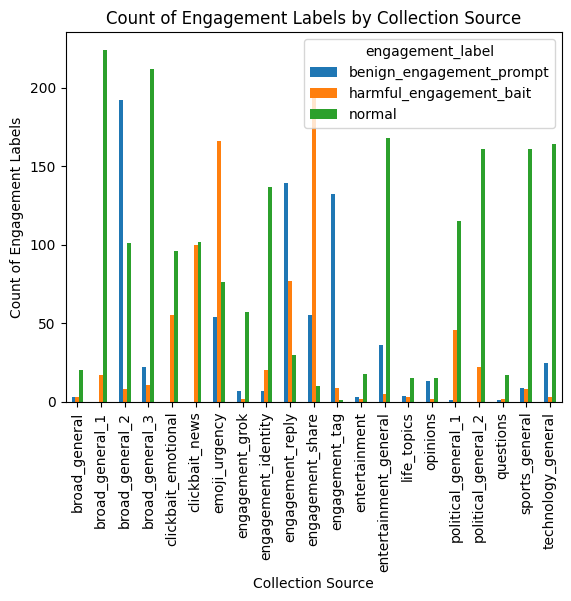

In [7]:
# Plotting engagement label distribution by collection source
count_bait_by_collection = model_df.groupby(['collection_source'])['engagement_label'].value_counts().unstack(fill_value=0)
count_bait_by_collection.plot(kind='bar', title='Count of Engagement Labels by Collection Source')
plt.xlabel('Collection Source')
plt.ylabel('Count of Engagement Labels')
plt.show()

The plot above shows that, outside of the prompts meant to collect tweets catered towards farming engagement, political tweets are the next most common source of harmuful engagement bait. For benign bait, the broad_general_2 query returned a large amount of harmless bait tweets. The words queried were: "good" OR "people" OR "today" OR "day". These are all common words used in greetings and small talk, which lines up with the amount of tweets classified as harmless bait.

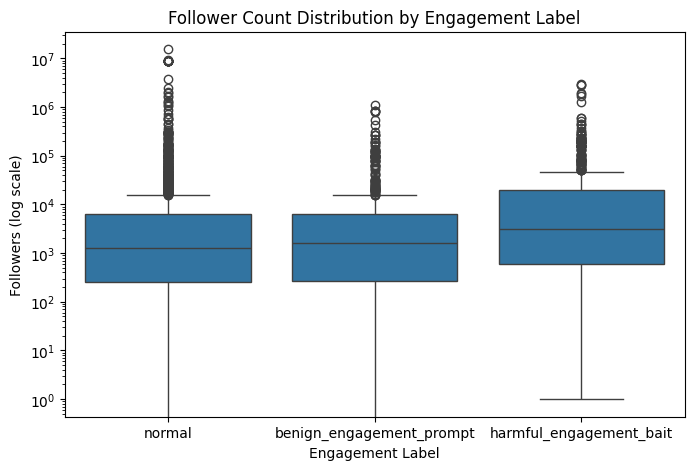

In [38]:
# Boxplot of followers count by engagement label
plt.figure(figsize=(8,5))
sns.boxplot(
    data=model_df,
    x='engagement_label',
    y='followers_count'
)
plt.title("Follower Count Distribution by Engagement Label")
plt.xlabel("Engagement Label")
plt.yscale('log') 
plt.ylabel("Followers (log scale)")
plt.show()

This boxplot displays the distribution of follower counts among tweets with each label. The box for harmful bait tweets is slightly higher than the other 2, while having a relatively similar quartile size. This suggests that harmful bait tweets originate from higher follower accounts on average. In context, this makes sense, as accounts with more followers and more reach have a higher tendency to want to drive engagement to further their platform, as "any press is good press".

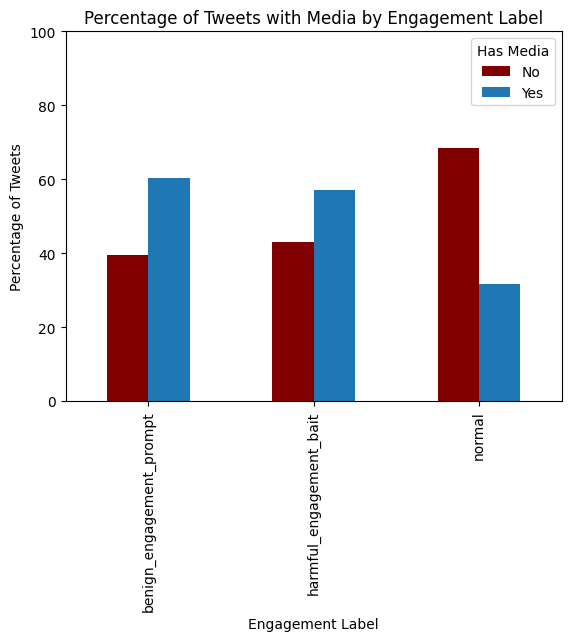

In [25]:
# Proportional media frequency in each type of tweet
media_by_label = (
    model_df.groupby('engagement_label')['has_media']
    .value_counts()
    .unstack(fill_value=0)
)

# Convert counts to proportions
media_by_label_pct = media_by_label.div(media_by_label.sum(axis=1), axis=0) * 100

media_by_label_pct.plot(
    kind='bar',
    stacked=False,
    color=['maroon', '#1f77b4'],
    title='Percentage of Tweets with Media by Engagement Label',
    xlabel='Engagement Label',
    ylabel='Percentage of Tweets'
)

plt.ylim(0, 100)
plt.legend(title='Has Media', labels=['No', 'Yes'])
plt.show()

The barplot above shows the proportion how many tweets of each label contained media. It is important to note that there was a much larger number of normal tweets collected in this analysis compared to the other 2 labeles, but by analyzing by proportion, the differences become clear. Bait tweets contain media much more often than normal tweets, indicating media is often a large factor in helping a tweet bait engagement in addition to text.

In [ ]:
# Identifying common words in each bait type (excluding stopwords)
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

eda_df = model_df.copy()

eda_df["eda_text"] = (
    eda_df["clean_text"]
    .fillna("")
)

# Remove URLs
eda_df["eda_text"] = eda_df["eda_text"].str.replace(r"http\S+", "", regex=True)

# Remove punctuation but KEEP capitalization
eda_df["eda_text"] = eda_df["eda_text"].str.replace(r"[^A-Za-z\s]", " ", regex=True)

# Collapse whitespace
eda_df["eda_text"] = eda_df["eda_text"].str.replace(r"\s+", " ", regex=True)


eda_df["tokens"] = eda_df["eda_text"].apply(
    lambda text: [
        word
        for word in text.split()
        if word.lower() not in stop_words
        and len(word) > 2
    ]
)
eda_df

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rj2wo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
def most_common_words(df, label, n=30):

    words = []

    subset = df[df["engagement_label"] == label]

    for tokens in subset["tokens"]:
        words.extend(tokens)

    return Counter(words).most_common(n)

normal_words = most_common_words(
    eda_df,
    "normal"
)

benign_words = most_common_words(
    eda_df,
    "benign_engagement_prompt"
)

harmful_words = most_common_words(
    eda_df,
    "harmful_engagement_bait"
)

normal_df = pd.DataFrame(
    normal_words,
    columns=["word","count"]
)

benign_df = pd.DataFrame(
    benign_words,
    columns=["word","count"]
)

harmful_df = pd.DataFrame(
    harmful_words,
    columns=["word","count"]
)

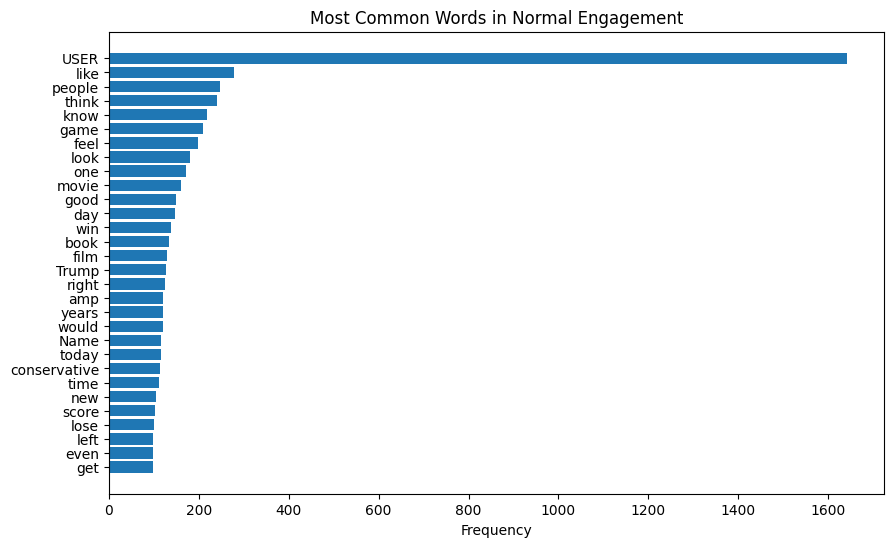

In [11]:
# Normal Plot
plt.figure(figsize=(10,6))

plt.barh(
    normal_df["word"],
    normal_df["count"]
)

plt.gca().invert_yaxis()

plt.title("Most Common Words in Normal Engagement")

plt.xlabel("Frequency")

plt.show()

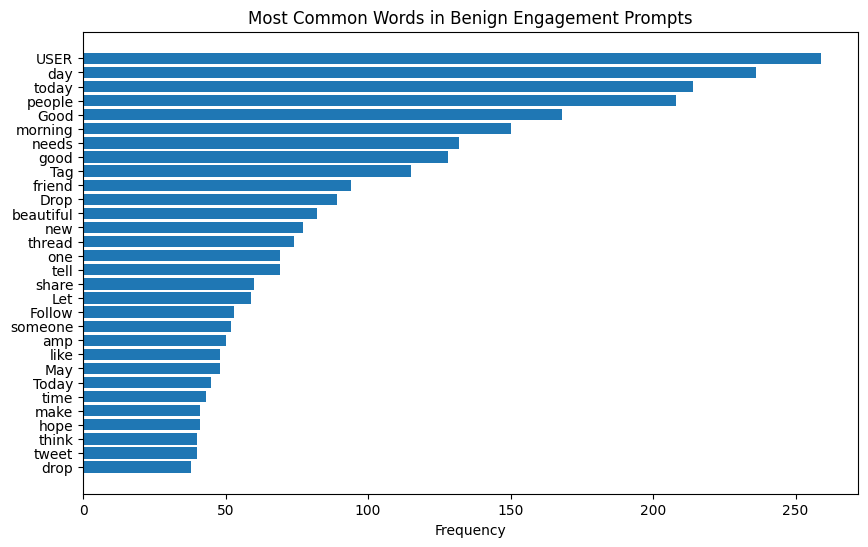

In [77]:
# Benign Plot
plt.figure(figsize=(10,6))

plt.barh(
    benign_df["word"],
    benign_df["count"]
)

plt.gca().invert_yaxis()

plt.title("Most Common Words in Benign Engagement Prompts")

plt.xlabel("Frequency")

plt.show()

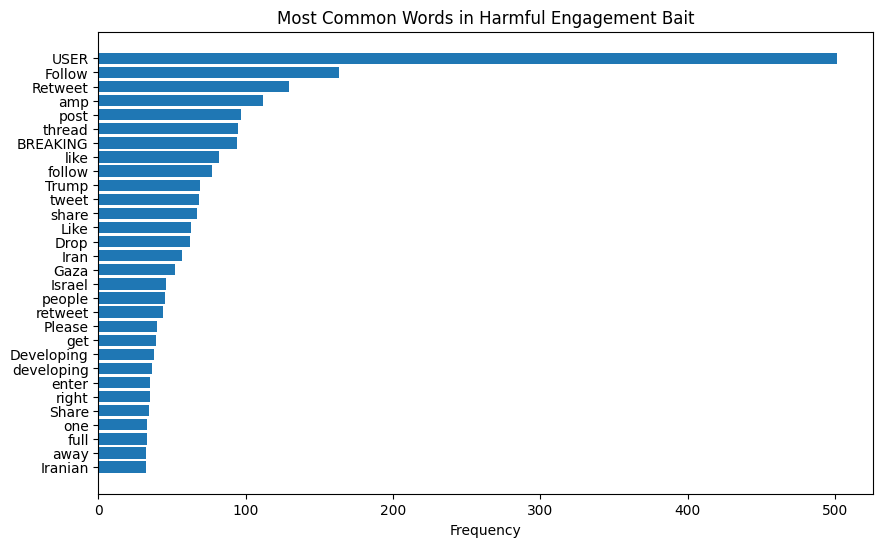

In [78]:

# Harmful Plot
plt.figure(figsize=(10,6))

plt.barh(
    harmful_df["word"],
    harmful_df["count"]
)

plt.gca().invert_yaxis()

plt.title("Most Common Words in Harmful Engagement Bait")

plt.xlabel("Frequency")

plt.show()

An important distinction to make for the 3 plots above is that USER is the most common, which indicates that the tweet was a reply to another tweet(s). We can cross reference the amount of tweets of each label with the proportion that included user to determine how significant a tweet being a reply was to their classification

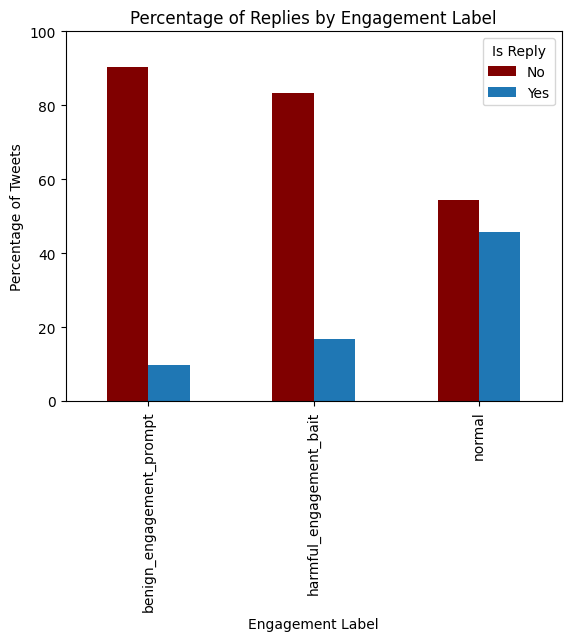

In [26]:
# Proportion of tweets that are replies by label

model_df["is_reply"] = model_df["text"].str.startswith("@")

reply_by_label = (
    model_df.groupby('engagement_label')['is_reply']
    .value_counts()
    .unstack(fill_value=0)
)

# Convert counts to proportions
reply_by_label_pct = reply_by_label.div(reply_by_label.sum(axis=1), axis=0) * 100

reply_by_label_pct.plot(
    kind='bar',
    stacked=False,
    color=['maroon', '#1f77b4'],
    title='Percentage of Replies by Engagement Label',
    xlabel='Engagement Label',
    ylabel='Percentage of Tweets'
)
plt.ylim(0, 100)
plt.legend(title='Is Reply', labels=['No', 'Yes'])
plt.show()

The plot above indicates that while replies were common across the entire dataset, the majority of both types of engagement bait were not replies. This is a surprising find, as especially for harmful bait, one would expect a reply to a user would be a common method of instigation, and therefore harmful engaement bait.

# Step 5.5: Exploratory PCA to address multicollinearity and redundant predictors

Before any modeling is completed, it is important to identify redundant predictors that could hinder our model's performace. The X/Twitter API scrapes a large number of statistics, and we need to eliminated the highly correlated ones in order to produce a model that works well. Principal Component Analysis will be used help identify these correlated predictors through reducing the dimensions of the data into groups (components) that we can interpret more clearly. 

In [18]:
# Exploratory PCA to determine redundant predictors

numeric_cols = [
    "text_length",
    "uppercase_ratio",
    "exclamation_count",
    "question_count",

    "like_count",
    "reply_count",
    "retweet_count",
    "quote_count",
    "engagement_total",
    "reply_like_ratio",
    "quote_like_ratio",

    "followers_count",
    "following_count",
    "user_tweet_count",
    "listed_count",
    "user_like_count",
    "user_media_count",
    "follower_following_ratio",

    "tweet_reported_media_count",
    "media_count_from_media_table",

    "num_photos",
    "num_videos",
    "num_gifs",

    "max_media_width",
    "max_media_height",
    "max_duration_ms",

    "avg_media_width",
    "avg_media_height"
]

X = model_df[numeric_cols].copy()

X = X.fillna(0)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

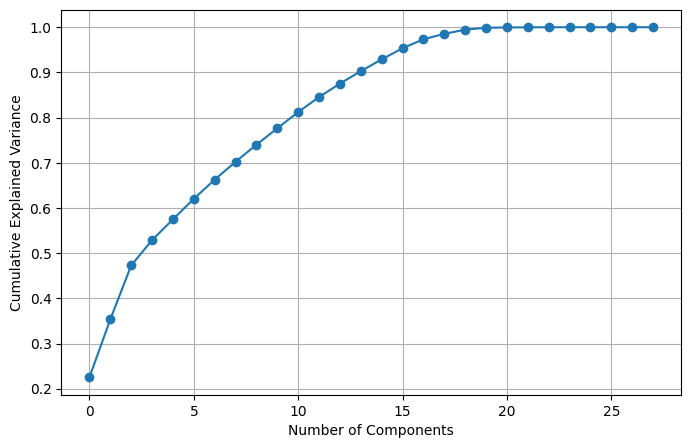

In [ ]:
# Scree plot
explained = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(explained),
    marker="o"
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.grid(True)

plt.show()

In [ ]:
# Component predictor loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[
        f"PC{i+1}"
        for i in range(len(X.columns))
    ]
)

display(loadings.round(3))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28
text_length,0.098,0.017,0.052,-0.043,-0.097,-0.046,-0.466,0.241,-0.239,0.223,...,0.028,0.016,-0.008,-0.002,0.001,0.000,-0.000,-0.000,0.000,-0.000
uppercase_ratio,0.112,-0.021,0.019,0.105,0.420,0.142,0.081,0.002,0.304,0.289,...,0.044,-0.003,-0.011,-0.000,-0.001,-0.001,0.000,0.000,0.000,0.000
exclamation_count,0.049,-0.034,-0.004,-0.016,0.453,0.467,0.065,-0.304,-0.009,0.255,...,-0.025,-0.004,0.000,0.007,-0.000,0.001,-0.000,-0.000,0.000,0.000
question_count,0.003,-0.005,-0.019,0.012,-0.291,0.334,-0.242,-0.177,-0.505,0.483,...,-0.012,-0.006,0.001,0.001,0.000,0.003,-0.000,-0.000,-0.000,-0.000
like_count,0.104,0.441,-0.219,-0.037,0.054,-0.083,-0.022,-0.013,-0.039,0.003,...,-0.056,0.003,0.006,0.000,-0.000,-0.000,0.077,-0.062,-0.068,-0.628
reply_count,0.089,0.376,-0.188,-0.087,-0.072,0.132,0.014,-0.054,-0.022,-0.170,...,0.085,-0.004,-0.002,0.001,-0.000,-0.000,0.008,-0.006,-0.007,-0.064
retweet_count,0.103,0.360,-0.169,0.001,0.071,-0.026,0.063,-0.017,-0.013,0.096,...,0.039,-0.006,-0.012,0.001,-0.000,-0.000,0.013,-0.010,-0.011,-0.105
quote_count,0.056,0.289,-0.137,0.006,-0.049,0.021,-0.128,-0.097,0.162,0.040,...,0.007,-0.015,-0.001,-0.000,-0.000,0.000,0.001,-0.001,-0.001,-0.007
engagement_total,0.111,0.458,-0.226,-0.038,0.049,-0.062,-0.010,-0.019,-0.035,0.002,...,-0.034,0.002,0.003,0.000,-0.000,-0.000,-0.091,0.073,0.081,0.745
reply_like_ratio,-0.055,0.014,-0.011,-0.198,-0.337,0.517,-0.016,0.056,0.038,-0.464,...,-0.014,0.005,0.004,-0.001,-0.001,0.000,0.000,-0.000,-0.000,-0.000


In [21]:
pc1 = (
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
)

display(pc1)

pc2 = (
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
)

display(pc2)

max_media_height                3.749623e-01
max_media_width                 3.723011e-01
avg_media_height                3.673002e-01
avg_media_width                 3.640686e-01
media_count_from_media_table    3.598031e-01
tweet_reported_media_count      3.566303e-01
num_photos                      3.162297e-01
num_videos                      1.324594e-01
uppercase_ratio                 1.119727e-01
engagement_total                1.105964e-01
like_count                      1.041026e-01
retweet_count                   1.034705e-01
text_length                     9.772092e-02
reply_count                     8.924103e-02
quote_count                     5.633563e-02
reply_like_ratio                5.506004e-02
max_duration_ms                 5.121662e-02
exclamation_count               4.891612e-02
user_tweet_count                3.588704e-02
follower_following_ratio        3.518956e-02
followers_count                 2.730575e-02
quote_like_ratio                1.735787e-02
following_

engagement_total                4.579017e-01
like_count                      4.410989e-01
reply_count                     3.759280e-01
retweet_count                   3.601701e-01
quote_count                     2.886454e-01
followers_count                 2.483559e-01
user_tweet_count                2.198148e-01
follower_following_ratio        2.195728e-01
listed_count                    2.032586e-01
num_photos                      7.964483e-02
following_count                 7.445345e-02
max_media_height                6.999777e-02
avg_media_height                6.765942e-02
media_count_from_media_table    6.730918e-02
tweet_reported_media_count      6.499954e-02
max_media_width                 5.542323e-02
avg_media_width                 5.204429e-02
max_duration_ms                 4.386913e-02
num_videos                      3.716924e-02
exclamation_count               3.378301e-02
num_gifs                        2.370507e-02
uppercase_ratio                 2.123513e-02
text_lengt

By exploring the predictors making up the majority of our first 3 principal components, we can see which predictors might be the most correlated with eachother, as well as what predictors contribute the most to data variation. The first couple values of PC1 are all media size and count statistics. This means that the largest variation in the data comes from these stats. PC2 captures an entirely new side to the data, which in this case is the engagement statistics of the tweet, likes, replies, etc. As is the nature of PCA, this component is uncorrelated to the media size stats, capturing the second most impactful source of variation in the dataset. However, for the purposes of this analysis, our main goal of PCA is to identify the groups of correlated predictors. So, for PC2, we can see that the engagement statistics are likely correlated with eachother, indicating not all of them should be included in modeling.

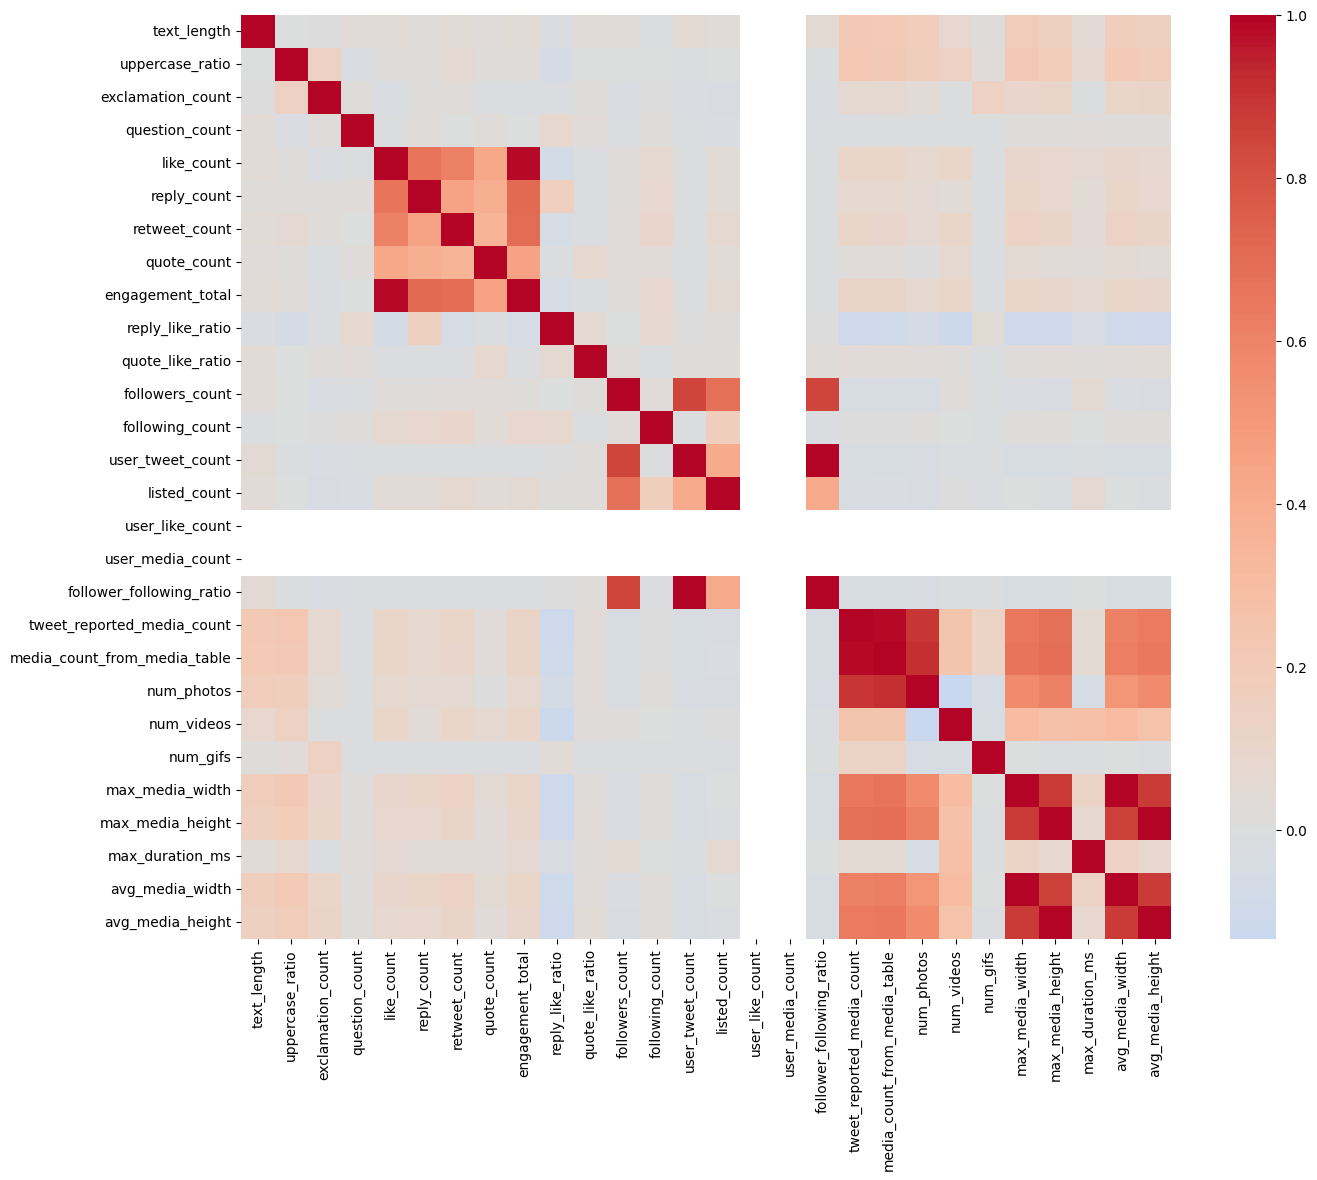

In [22]:
plt.figure(figsize=(15,12))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.show()

After exploring the correlation matrix, we have sufficient evidence to conlclude that the media details and engagement statistics are largely correlated with eachother, indicated by the red boxes in the matrix. While it is impossible to perform PCA on the non-numeric predictors in our data (which will likely be the most important factors), ensuring the correct summary statistics are included in our model without their correlated counterparts is essential. For the initial model, the following numeric predictors are chosen, based on their lack of correlation with other variables, or their significance without their correlated counterparts.

text_length, uppercase_ratio, exlamation_count, question_count, followers_count, following_count, user_tweet_count, user_media_count, num_photos, num_vidoes, num_gifs, max_duration_ms, avg_media_width

# Step 6: Model Training and Evaluation

Using our new predictor set, the first step of model training is to train a random forest model to see how well we can predict the engagement lavel WITHOUT the text input. The results of this model will be used to determine if the feature set needs to be altered, as well as generally seeing how impacful the numerical statistcs are in determining the engagement label.

In [ ]:
# Redundant variables excluded form model training
X = model_df[[
    'text_length','uppercase_ratio','exclamation_count','question_count',
    'has_url','has_mention','has_hashtag','verified','followers_count','following_count','user_tweet_count','user_media_count',
    'num_photos','num_videos','num_gifs','max_duration_ms','avg_media_width'
]]
Y=model_df['engagement_label']

encoder = LabelEncoder()

Y = encoder.fit_transform(Y)

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

# Hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Base model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Grid Search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1_macro',  
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, Y_train)

best_rf = grid_rf.best_estimator_

print(grid_rf.best_params_)
print(grid_rf.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
{'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
0.6640822615105997


                          precision    recall  f1-score   support

benign_engagement_prompt       0.64      0.56      0.60       141
 harmful_engagement_bait       0.59      0.48      0.53       151
                  normal       0.77      0.86      0.81       380

                accuracy                           0.71       672
               macro avg       0.66      0.63      0.64       672
            weighted avg       0.70      0.71      0.70       672



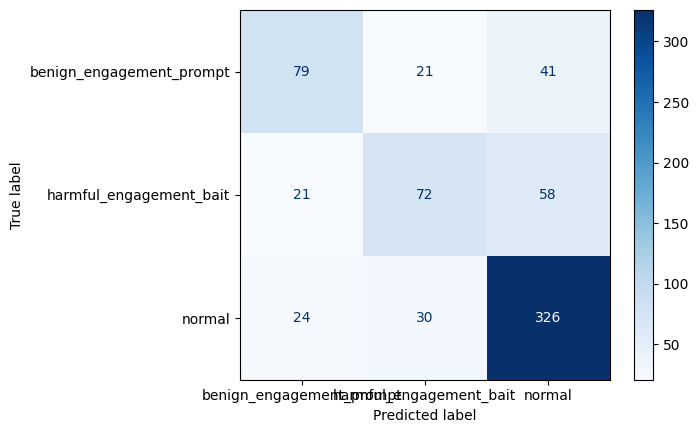

In [9]:
predictions = best_rf.predict(X_test)

print(classification_report(
    Y_test,
    predictions,
    target_names=encoder.classes_
))


ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    Y_test,
    display_labels=encoder.classes_,
    cmap="Blues"
)

Our initial model sports a 71% accuracy without the text input, indicating that the numerical statistics chosen still are quite good at predicting the label of a tweet. Out of the 3 labels, normal tweets had the highest precision and recall, indicating our model is pretty good at correctly identifying a true normal tweet out of the total and predicted normal tweets. The model does suffer in predictive accuracy however when predicting benign or harmful cases, with much lower scores in recall and precision. While this could be a result of the difference in sample size in our original data, this finding suggests that the model without text is very likely to predict normal over either type of bait, indicating that a model with textual input will most likely be much more helpful in detecting bait. Without textual context, it is very difficult to tell the difference between tweets with similar summary statistics. To determine if our feature set needs any changes before using a different model that can incorporate text, a feature importance check can be run.

In [11]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance["Cumulative"] = (
   importance["Importance"].cumsum()
)

display(importance.head(20))

,Feature,Importance,Cumulative
0,text_length,0.161829,0.161829
1,uppercase_ratio,0.148572,0.310401
8,followers_count,0.125122,0.435523
10,user_tweet_count,0.117729,0.553252
9,following_count,0.115826,0.669078
16,avg_media_width,0.073618,0.742696
2,exclamation_count,0.068383,0.811079
3,question_count,0.035409,0.846489
4,has_url,0.033156,0.879645
15,max_duration_ms,0.028142,0.907787


Examining our feature importance reveals some major insights. The most important factors were text_length and the amount of uppercase letters. This makes sense in context, as bait tweets are more likely to include large amounts of text and capitals in order to capture and hold a reader's attention. A surprising insight from these numbers is the lack of importance from having a hashtag. Hashtags are very common indicators of bait, most likely benign, as the labeler was instructed, but the model doesn't value them as highly. For our next model, we will keep all the predictors that account for the top ~95% of data, so everything up to has_mention.

In [ ]:
X = model_df[[
    'text_length','uppercase_ratio','exclamation_count','question_count',
    'has_url','has_mention','followers_count','following_count','user_tweet_count',
    'max_duration_ms','avg_media_width'
]]
Y=model_df['engagement_label']

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

param_grid_rf = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Base model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Grid Search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1_macro',      
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, Y_train)

best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 162 candidates, totalling 810 fits


                          precision    recall  f1-score   support

benign_engagement_prompt       0.63      0.56      0.59       141
 harmful_engagement_bait       0.64      0.50      0.56       151
                  normal       0.77      0.87      0.82       380

                accuracy                           0.72       672
               macro avg       0.68      0.64      0.66       672
            weighted avg       0.71      0.72      0.71       672



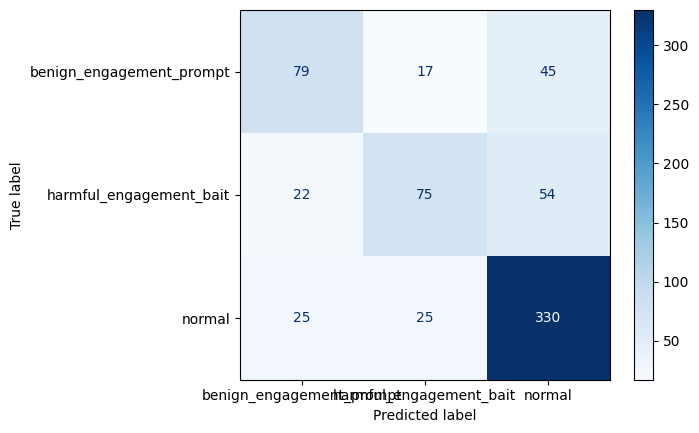

In [13]:
predictions = best_rf.predict(X_test)

print(classification_report(
    Y_test,
    predictions,
    target_names=encoder.classes_
))


ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    Y_test,
    display_labels=encoder.classes_,
    cmap="Blues"
)

After removing the least important predictors, we can observe a slight increase in precision and recall among the 2 bait types. This indicates our new predictor set should serve as a stronger baseline when incorporating textual data. Now, we will incorporate textual data using an XGBoost model. Because XGBoost is unable to take raw textual data as an input, we need to use the TfidfVectorizer in order to transform the text into numbers for the model to be able to read.

In [14]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9
)

X_text = tfidf.fit_transform(model_df["clean_text"])

In [22]:
X_meta = model_df[[
    'text_length','uppercase_ratio','exclamation_count','question_count',
    'has_url','has_mention','followers_count','following_count','user_tweet_count',
    'max_duration_ms','avg_media_width'
]]
X_meta = X_meta.fillna(0)
X = hstack([X_text, X_meta.values])

encoder = LabelEncoder()

Y = encoder.fit_transform(model_df["engagement_label"])


X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=.20,
    random_state=42,
    stratify=Y
)

# Hyperparameter grid
param_grid_xgb = {

    'n_estimators': [50, 100, 200, 400],

    'learning_rate': [0.01, 0.03, 0.05, 0.1],

    'max_depth': [2, 3, 5, 7],

    'subsample': [0.6, 0.8, 1.0],

    'colsample_bytree': [0.6, 0.8, 1.0],

    'min_child_weight': [1, 3, 5],

    'gamma': [0, 0.25, 0.5, 1],

    'reg_alpha': [0, 0.1, 1],

    'reg_lambda': [1, 2, 5]
}

# Base model
xgb = XGBClassifier(
    random_state=42,
    n_jobs=-1
)

# Grid Search
grid_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid_xgb,
    n_iter=50,
    cv=5,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1
)

grid_xgb.fit(X_train, Y_train)

best_xgb = grid_xgb.best_estimator_

print(grid_xgb.best_params_)
print(grid_xgb.best_score_)

{'subsample': 0.6, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6}
0.7677612630192121


                          precision    recall  f1-score   support

benign_engagement_prompt       0.76      0.64      0.69       141
 harmful_engagement_bait       0.78      0.64      0.70       151
                  normal       0.82      0.92      0.87       380

                accuracy                           0.80       672
               macro avg       0.78      0.73      0.75       672
            weighted avg       0.80      0.80      0.79       672



,feature,importance
4520,thread audience,0.016593
3775,retweet,0.015977
4424,tag,0.013913
349,app development,0.013349
1668,gaza,0.012734
2874,ml,0.012713
1535,follow,0.012369
3845,rt tweet,0.011968
1600,friend needs,0.011951
3844,rt,0.010956


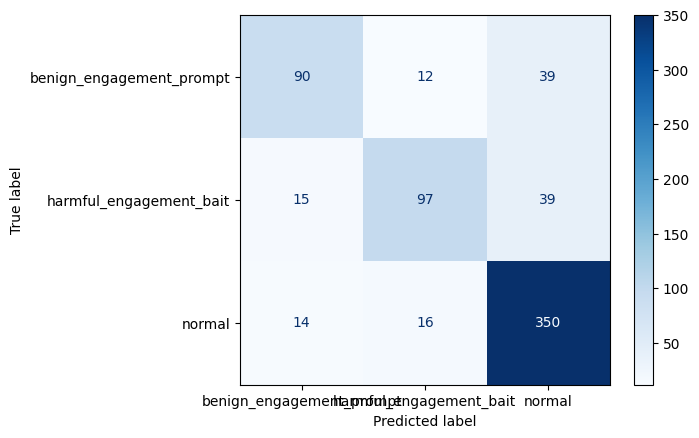

In [23]:
predictions = best_xgb.predict(X_test)

print(
    classification_report(
        Y_test,
        predictions,
        target_names=encoder.classes_
    )
)

ConfusionMatrixDisplay.from_estimator(
    best_xgb,
    X_test,
    Y_test,
    display_labels=encoder.classes_,
    cmap="Blues"
)
importance = pd.DataFrame({
    "feature": tfidf.get_feature_names_out().tolist() + list(X_meta.columns),
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(30))
# group importance by engagement_label

Incorporating text defenitely helps the model's predictive accuracy, jumping from 72% to 80%. Taking a glance at our most impactful words reveals common X/Twitter language like retweet, tag, and follow are among the most impactful words for making accurate predicts, which is an unsurprising finding. XGBoost is a good alternative model to include text, but due to the nature of the vectorization necessary, the model is unable to capture things like context as well as more specialized textual ML models. From the XGBoost model, we learn that textual input does improve model performance, but we can potentially discover a stronger model when incorporating context into the equation.

# Step 7: Final roBERTa model training/testing

In order to properly account for context within each tweet and their classification, the roBERTa model is chosen, developed by MetaAI in 2019. This model builds on the common BERT model developed by Google in 2018, which was revolutionary at the time due to its abiltity to analyze text and context from both the words behind and in front of the current word, which is used to predict the next words/sentences. roBERTa builds on top of the BERT model by training on roughly 10 times more data, and removing the next sentence predicton element, focusing purely on current sentence context. This alligns with the structure of the X/Twitter data very well, as our goal is to predict engagement bait or not using a single tweet, and not caring about what may come next in a thread or larger article. roBERTa also contains a much larger vocabulary than BERT, which could help interpret any slang or new pop culture terms present in recent tweets.

Before the final model is trained and analyzed, hyperparameter tuning must be performed to find the optimal parameters for our final model. The training data is split into 64/16 analysis/validation sets in order to perform this process. Once the optimal hyperparameters are identified, we will combine the training data once again and use the testing set as validation. One important note is that, because we have an imbalance of class distribution in our data (many more normal tweets than benign/harmful) our primary evaluation metric will be macro f1 rather than accuracy, due to it's ability to handle class imbalances more effectively.

In [37]:
X_text = model_df["clean_text"].fillna("")

X_meta = model_df[[
    "text_length",
    "uppercase_ratio",
    "exclamation_count",
    "question_count",
    "has_url",
    "has_mention",
    "followers_count",
    "following_count",
    "user_tweet_count",
    "max_duration_ms",
    "avg_media_width"
]].fillna(0)

encoder = LabelEncoder()
Y = encoder.fit_transform(model_df["engagement_label"])

# First split: reserve 20% as untouched test data
(
    X_train_text,
    X_test_text,
    X_train_meta,
    X_test_meta,
    Y_train,
    Y_test
) = train_test_split(
    X_text,
    X_meta,
    Y,
    test_size=0.20,
    stratify=Y,
    random_state=42
)

# Second split: divide remaining 80% into training and validation
(
    X_train_text,
    X_val_text,
    X_train_meta,
    X_val_meta,
    Y_train,
    Y_val
) = train_test_split(
    X_train_text,
    X_train_meta,
    Y_train,
    test_size=0.20,
    stratify=Y_train,
    random_state=42
)

print("Training rows:", len(Y_train))
print("Validation rows:", len(Y_val))
print("Test rows:", len(Y_test))

Training rows: 2148
Validation rows: 538
Test rows: 672


In [38]:
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

train_dataset = Dataset.from_dict({
    "text": X_train_text.tolist(),
    "labels": Y_train.tolist()
})

val_dataset = Dataset.from_dict({
    "text": X_val_text.tolist(),
    "labels": Y_val.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test_text.tolist(),
    "labels": Y_test.tolist()
})

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(
            labels,
            predictions,
            average="macro"
        )
    }

Map:   0%|          | 0/2148 [00:00<?, ? examples/s]

Map:   0%|          | 0/538 [00:00<?, ? examples/s]

Map:   0%|          | 0/672 [00:00<?, ? examples/s]

In [ ]:
configurations = [
    {
        "name": "lr2e-5_bs16_ep3",
        "learning_rate": 2e-5,
        "batch_size": 16,
        "epochs": 3,
        "weight_decay": 0.01
    },
    {
        "name": "lr2e-5_bs16_ep4",
        "learning_rate": 2e-5,
        "batch_size": 16,
        "epochs": 4,
        "weight_decay": 0.01
    },
    {
        "name": "lr3e-5_bs16_ep4",
        "learning_rate": 3e-5,
        "batch_size": 16,
        "epochs": 4,
        "weight_decay": 0.01
    },
    {
        "name": "lr5e-5_bs16_ep3",
        "learning_rate": 5e-5,
        "batch_size": 16,
        "epochs": 3,
        "weight_decay": 0.01
    },
    {
        "name": "lr2e-5_bs8_ep4",
        "learning_rate": 2e-5,
        "batch_size": 8,
        "epochs": 4,
        "weight_decay": 0.01
    }
]

In [39]:
results = []

for config_number, config in enumerate(configurations, start=1):
    print("=" * 100)
    print(
        f"Training configuration {config_number}/{len(configurations)}: "
        f"{config['name']}"
    )

    output_dir = f"./results/{config['name']}"

    # Start every configuration from fresh pretrained weights
    model = RobertaForSequenceClassification.from_pretrained(
        "roberta-base",
        num_labels=len(encoder.classes_),
        id2label={
            class_id: label
            for class_id, label in enumerate(encoder.classes_)
        },
        label2id={
            label: class_id
            for class_id, label in enumerate(encoder.classes_)
        }
    )

    training_args = TrainingArguments(
        output_dir=output_dir,

        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",

        learning_rate=config["learning_rate"],
        per_device_train_batch_size=config["batch_size"],
        per_device_eval_batch_size=config["batch_size"],
        num_train_epochs=config["epochs"],
        weight_decay=config["weight_decay"],

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        save_total_limit=1,
        report_to="none",
        seed=42
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()

    # Evaluate the best checkpoint on validation data
    eval_results = trainer.evaluate(val_dataset)

    model_path = os.path.join(output_dir, "best_model")

    trainer.save_model(model_path)
    tokenizer.save_pretrained(model_path)

    results.append({
        "configuration": config["name"],
        "learning_rate": config["learning_rate"],
        "batch_size": config["batch_size"],
        "epochs": config["epochs"],
        "weight_decay": config["weight_decay"],
        "validation_loss": eval_results.get("eval_loss"),
        "validation_accuracy": eval_results.get("eval_accuracy"),
        "validation_macro_f1": eval_results.get("eval_f1"),
        "model_path": model_path
    })

    # Free memory before starting the next configuration
    del trainer
    del model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Training configuration 1/5: lr2e-5_bs16_ep3


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
c:\Users\rj2wo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device 

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.695333,0.437283,0.842007,0.793324
2,0.345837,0.447884,0.832714,0.818896
3,0.234413,0.387002,0.871747,0.849451


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

c:\Users\rj2wo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\rj2wo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.133694,0.528405,4,0.879182,0.861538


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [42]:
results_df = (
    pd.DataFrame(results)
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(results_df)

best_config = results_df.iloc[0]

print("Best configuration:")
print(best_config)

,configuration,learning_rate,batch_size,epochs,weight_decay,validation_loss,validation_accuracy,validation_macro_f1,model_path
0,lr5e-5_bs16_ep3,0.00005,16,3,0.01,0.390869,0.886617,0.868941,./results/lr5e-5_bs16_ep3\best_model
1,lr3e-5_bs16_ep4,0.00003,16,4,0.01,0.403525,0.890335,0.868418,./results/lr3e-5_bs16_ep4\best_model
2,lr2e-5_bs16_ep4,0.00002,16,4,0.01,0.397909,0.890335,0.868243,./results/lr2e-5_bs16_ep4\best_model
3,lr2e-5_bs8_ep4,0.00002,8,4,0.01,0.528405,0.879182,0.861538,./results/lr2e-5_bs8_ep4\best_model
4,lr2e-5_bs16_ep3,0.00002,16,3,0.01,0.387002,0.871747,0.849451,./results/lr2e-5_bs16_ep3\best_model


Best configuration:
configuration                               lr5e-5_bs16_ep3
learning_rate                                       0.00005
batch_size                                               16
epochs                                                    3
weight_decay                                           0.01
validation_loss                                    0.390869
validation_accuracy                                0.886617
validation_macro_f1                                0.868941
model_path             ./results/lr5e-5_bs16_ep3\best_model
Name: 0, dtype: object


In [43]:
# Load best saved model
best_model = RobertaForSequenceClassification.from_pretrained(
    best_config["model_path"]
)

trainer = Trainer(model=best_model)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# Predict on untouched test set using optimal configuration
predictions = trainer.predict(test_dataset)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

true_labels = np.array(Y_test)

c:\Users\rj2wo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification Report

                          precision    recall  f1-score   support

benign_engagement_prompt       0.83      0.74      0.79       141
 harmful_engagement_bait       0.74      0.79      0.76       151
                  normal       0.90      0.91      0.90       380

                accuracy                           0.85       672
               macro avg       0.82      0.81      0.82       672
            weighted avg       0.85      0.85      0.85       672



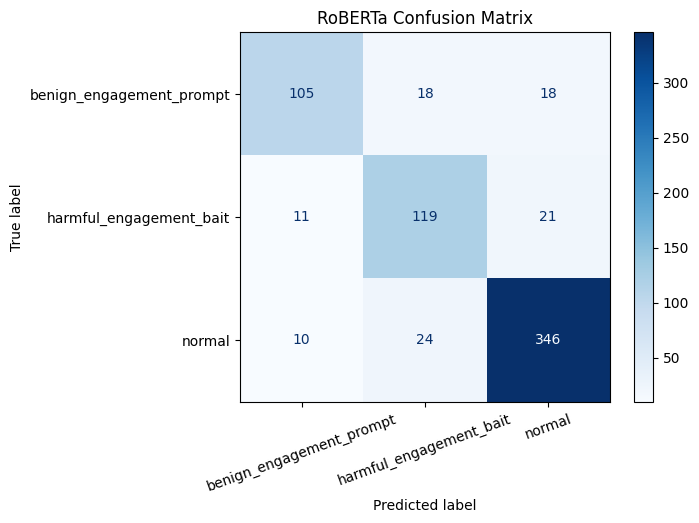

,Accuracy,Macro Precision,Macro Recall,Macro F1
0,0.8482,0.8237,0.8144,0.818


In [47]:
print("Classification Report\n")

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=encoder.classes_
    )
)

import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predicted_labels,
    display_labels=encoder.classes_,
    cmap="Blues",
    xticks_rotation=20
)

plt.title("RoBERTa Confusion Matrix")
plt.show()

summary = pd.DataFrame({
    "Accuracy": [accuracy_score(true_labels, predicted_labels)],
    "Macro Precision": [precision_score(true_labels, predicted_labels, average="macro")],
    "Macro Recall": [recall_score(true_labels, predicted_labels, average="macro")],
    "Macro F1": [f1_score(true_labels, predicted_labels, average="macro")]
})

display(summary.round(4))

The roBERTa model improves over the XGBoost model by about 5%, even without training on the full training set. For the final model, the optimal parametes will be tested on the original 80% training set, and tested on the same test set. Then, we will train one final model that DOES include the metadata we trained on earlier, and seeing which model is superior.

# Step 7.5: Final Model Training/Testing and Comparison (Metadata Included vs Excluded)

In [ ]:
# Final Model (NO METADATA)
X_text = model_df["clean_text"]

X_meta = model_df[[
    'text_length',
    'uppercase_ratio',
    'exclamation_count',
    'question_count',
    'has_url',
    'has_mention',
    'followers_count',
    'following_count',
    'user_tweet_count',
    'max_duration_ms',
    'avg_media_width'
]].fillna(0)

encoder = LabelEncoder()

Y = encoder.fit_transform(model_df["engagement_label"])

X_train_text, X_test_text, \
X_train_meta, X_test_meta, \
Y_train, Y_test = train_test_split(

    X_text,
    X_meta,
    Y,

    test_size=.20,
    stratify=Y,
    random_state=42
)

tokenizer = RobertaTokenizer.from_pretrained(
    "roberta-base"
)

train_dataset = Dataset.from_dict({
    "text": X_train_text.tolist(),
    "label": Y_train
})

test_dataset = Dataset.from_dict({
    "text": X_test_text.tolist(),
    "label": Y_test
})

def tokenize(batch):

    return tokenizer(

        batch["text"],

        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

train_dataset = train_dataset.remove_columns(
    ["text"]
)

test_dataset = test_dataset.remove_columns(
    ["text"]
)

train_dataset.set_format("torch")

test_dataset.set_format("torch")

model = RobertaForSequenceClassification.from_pretrained(

    "roberta-base",

    num_labels=3
)

Map:   0%|          | 0/2686 [00:00<?, ? examples/s]

Map:   0%|          | 0/672 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [49]:
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True
)

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)

In [50]:
trainer.train()

c:\Users\rj2wo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,0.428390
2,No log,0.398620
3,0.376506,0.441559


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\rj2wo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\rj2wo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=504, training_loss=0.37541765802436405, metrics={'train_runtime': 3368.4006, 'train_samples_per_second': 2.392, 'train_steps_per_second': 0.15, 'total_flos': 530041980013056.0, 'train_loss': 0.37541765802436405, 'epoch': 3.0})

c:\Users\rj2wo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


                          precision    recall  f1-score   support

benign_engagement_prompt       0.84      0.80      0.82       141
 harmful_engagement_bait       0.83      0.78      0.80       151
                  normal       0.89      0.92      0.91       380

                accuracy                           0.87       672
               macro avg       0.85      0.84      0.84       672
            weighted avg       0.86      0.87      0.87       672



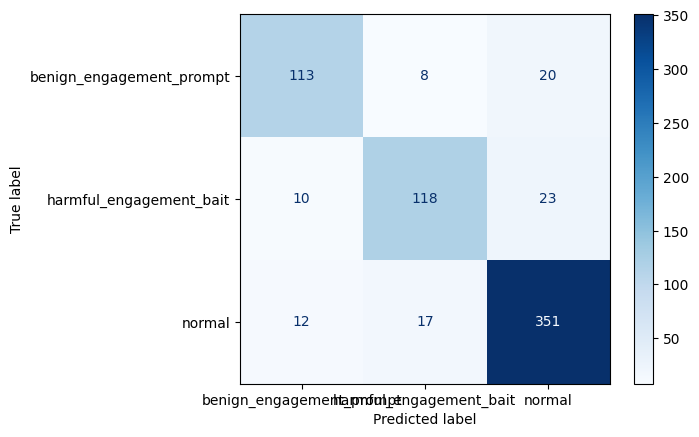

In [51]:
predictions = trainer.predict(test_dataset)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

print(classification_report(

    Y_test,

    predicted_labels,

    target_names=encoder.classes_
))

ConfusionMatrixDisplay.from_predictions(

    Y_test,

    predicted_labels,

    display_labels=encoder.classes_,

    cmap="Blues"
)

Training using the entire training set using the optimal parametes results in our highest accuracy and f1 scores yet. For the final comparison, we will test the same parameters while including metadata.

In [5]:
# Metadata Included Model
X_text = model_df["clean_text"].fillna("")

metadata_columns = [
    "text_length",
    "uppercase_ratio",
    "exclamation_count",
    "question_count",
    "has_url",
    "has_mention",
    "followers_count",
    "following_count",
    "user_tweet_count",
    "max_duration_ms",
    "avg_media_width"
]

X_meta = model_df[metadata_columns].fillna(0).copy()

encoder = LabelEncoder()
Y = encoder.fit_transform(model_df["engagement_label"])

(
    X_train_text,
    X_test_text,
    X_train_meta,
    X_test_meta,
    Y_train,
    Y_test
) = train_test_split(
    X_text,
    X_meta,
    Y,
    test_size=0.20,
    stratify=Y,
    random_state=42
)

In [6]:


meta_scaler = StandardScaler()

X_train_meta_scaled = meta_scaler.fit_transform(X_train_meta)
X_test_meta_scaled = meta_scaler.transform(X_test_meta)

X_train_meta_scaled = X_train_meta_scaled.astype("float32")
X_test_meta_scaled = X_test_meta_scaled.astype("float32")

In [7]:

joblib.dump(meta_scaler, "roberta_metadata_scaler.joblib")

['roberta_metadata_scaler.joblib']

In [8]:


train_dataset = Dataset.from_dict({
    "text": X_train_text.tolist(),
    "metadata": X_train_meta_scaled.tolist(),
    "labels": Y_train.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test_text.tolist(),
    "metadata": X_test_meta_scaled.tolist(),
    "labels": Y_test.tolist()
})

In [9]:


tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "metadata",
        "labels"
    ]
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "metadata",
        "labels"
    ]
)

Map:   0%|          | 0/2686 [00:00<?, ? examples/s]

Map:   0%|          | 0/672 [00:00<?, ? examples/s]

In [10]:
print(train_dataset[0].keys())
print(train_dataset[0]["metadata"].shape)

dict_keys(['metadata', 'labels', 'input_ids', 'attention_mask'])
torch.Size([11])


In [12]:
class RobertaWithMetadata(nn.Module):
    def __init__(
        self,
        model_name: str,
        num_metadata_features: int,
        num_labels: int,
        metadata_hidden_size: int = 32,
        dropout_rate: float = 0.2
    ):
        super().__init__()

        self.roberta = RobertaModel.from_pretrained(model_name)

        roberta_hidden_size = self.roberta.config.hidden_size

        # Transform the structured metadata before combining it with text
        self.metadata_network = nn.Sequential(
            nn.Linear(num_metadata_features, metadata_hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )

        self.dropout = nn.Dropout(dropout_rate)

        # Combined RoBERTa representation + processed metadata
        self.classifier = nn.Linear(
            roberta_hidden_size + metadata_hidden_size,
            num_labels
        )

        self.loss_function = nn.CrossEntropyLoss()

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        metadata=None,
        labels=None,
        **kwargs
    ):
        roberta_outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Representation of RoBERTa's first token
        text_features = roberta_outputs.last_hidden_state[:, 0, :]

        metadata = metadata.float()
        metadata_features = self.metadata_network(metadata)

        combined_features = torch.cat(
            [text_features, metadata_features],
            dim=1
        )

        combined_features = self.dropout(combined_features)
        logits = self.classifier(combined_features)

        loss = None

        if labels is not None:
            loss = self.loss_function(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=roberta_outputs.hidden_states,
            attentions=roberta_outputs.attentions
        )

In [13]:
model = RobertaWithMetadata(
    model_name="roberta-base",
    num_metadata_features=len(metadata_columns),
    num_labels=len(encoder.classes_),
    metadata_hidden_size=32,
    dropout_rate=0.2
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:

training_args = TrainingArguments(
    output_dir="./results/roberta_with_metadata",

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1,
    report_to="none",
    seed=42
)

In [15]:

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(
            labels,
            predictions,
            average="macro"
        )
    }

In [16]:

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

c:\Users\rj2wo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.618962,0.450812,0.830357,0.794117
2,0.325655,0.501836,0.836310,0.796098
3,0.170318,0.557956,0.860119,0.837614


c:\Users\rj2wo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\rj2wo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=504, training_loss=0.3716449396950858, metrics={'train_runtime': 2501.7097, 'train_samples_per_second': 3.221, 'train_steps_per_second': 0.201, 'total_flos': 0.0, 'train_loss': 0.3716449396950858, 'epoch': 3.0})

c:\Users\rj2wo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


                          precision    recall  f1-score   support

benign_engagement_prompt       0.85      0.78      0.81       141
 harmful_engagement_bait       0.76      0.83      0.80       151
                  normal       0.91      0.90      0.90       380

                accuracy                           0.86       672
               macro avg       0.84      0.84      0.84       672
            weighted avg       0.86      0.86      0.86       672



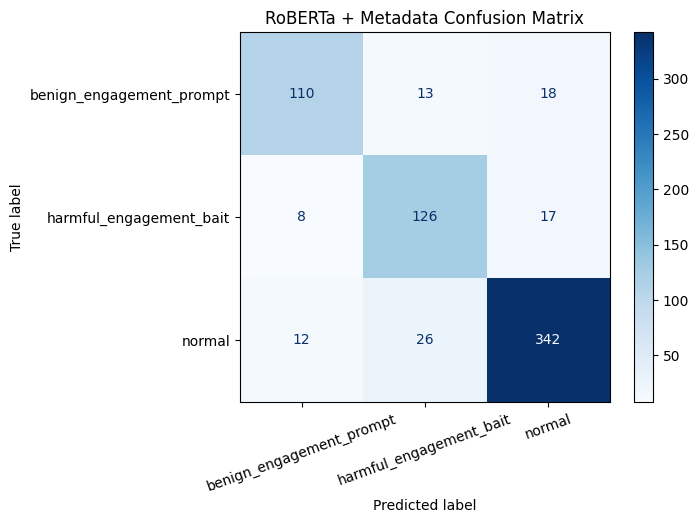

In [17]:
prediction_output = trainer.predict(test_dataset)

predicted_labels = np.argmax(
    prediction_output.predictions,
    axis=1
)

print(
    classification_report(
        Y_test,
        predicted_labels,
        target_names=encoder.classes_
    )
)

ConfusionMatrixDisplay.from_predictions(
    Y_test,
    predicted_labels,
    display_labels=encoder.classes_,
    cmap="Blues",
    xticks_rotation=20
)

plt.title("RoBERTa + Metadata Confusion Matrix")
plt.show()

In [18]:
comparison_df = pd.DataFrame({
    "model": [
        "RoBERTa text only",
        "RoBERTa text + metadata"
    ],
    "accuracy": [
        text_only_accuracy,
        hybrid_accuracy
    ],
    "macro_f1": [
        text_only_macro_f1,
        hybrid_macro_f1
    ]
})

display(comparison_df)

NameError: name 'text_only_accuracy' is not defined

Our final model with metadata included performs very close to, but slightly worse than our text-only model in terms of accuracy and macro f1. This indicates that, when determining the classification of a tweet, the text is easily the primary indicator, and metadata doesn't do much in order to help with the classification. While it isn't necessarily harmful, it also isn't significant enough to increase model performance over text-only.

# STEP 8: Final Discussion and Conclusion

SUMMARY:

IMPLICATIONS:

LIMITATIONS:

FUTURE IMPROVEMENTS:

CONCLUSION: